In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
file_path = "CHURN_DATASET.xlsx"

df = pd.read_excel(file_path, sheet_name="churn_dataset")

In [3]:
df.head()

,customer_id,age,gender,subscription_type,signup_date,last_active_date,monthly_spend,num_logins_last_month,num_support_tickets,is_auto_renew,used_mobile_app,num_referrals,avg_session_duration_minutes,credit_score,churned
0,CUST10000,56.0,Male,Basic,2020-12-13 23:45:47,2023-12-20 01:39:32,69.71,25.0,3.0,1.0,1.0,9.0,42.94,655.0,1.0
1,CUST10001,69.0,Female,Basic,2021-02-01 03:56:28,2023-12-02 09:05:00,43.38,17.0,2.0,1.0,1.0,5.0,22.25,611.0,1.0
2,CUST10002,46.0,Other,Basic,2022-03-29 10:59:44,2024-10-04 08:32:30,40.67,16.0,3.0,1.0,0.0,8.0,31.25,611.0,1.0
3,CUST10003,32.0,Other,Basic,2019-08-20 11:26:08,2024-02-13 02:28:34,41.69,20.0,0.0,NaN,0.0,6.0,22.17,632.0,NaN
4,CUST10004,60.0,Other,Premium,2021-09-15 17:49:37,2023-02-10 17:54:38,63.52,16.0,5.0,1.0,NaN,8.0,26.86,643.0,0.0


## EDA

In [4]:
print(df.shape)

(1500, 15)


In [5]:
print(df.isnull().sum())
print(df.info())

customer_id                      94
age                              96
gender                          115
subscription_type                96
signup_date                     110
last_active_date                 99
monthly_spend                    93
num_logins_last_month            91
num_support_tickets              93
is_auto_renew                   103
used_mobile_app                  97
num_referrals                   118
avg_session_duration_minutes    113
credit_score                     82
churned                         114
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   customer_id                   1406 non-null   str           
 1   age                           1404 non-null   float64       
 2   gender                        1385 non-null   str           
 3   subscription_typ

In [6]:
df.describe(include='all')

,customer_id,age,gender,subscription_type,signup_date,last_active_date,monthly_spend,num_logins_last_month,num_support_tickets,is_auto_renew,used_mobile_app,num_referrals,avg_session_duration_minutes,credit_score,churned
count,1406,1404.000000,1385,1404,1390,1401,1407.000000,1409.000000,1407.00000,1397.000000,1403.000000,1382.000000,1387.000000,1418.000000,1386.000000
unique,1406,NaN,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,CUST10000,NaN,Male,Free,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,470,493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,49.076923,NaN,NaN,2020-06-25 16:27:55.458992,2024-01-03 11:54:29.391149,53.487499,20.058197,2.03838,0.503221,0.526016,4.397250,32.194379,661.136686,0.474747
min,NaN,18.000000,NaN,NaN,2018-01-01 13:52:56,2023-01-02 01:47:44,4.310000,5.000000,0.00000,0.000000,0.000000,0.000000,-6.350000,503.000000,0.000000
25%,NaN,34.000000,NaN,NaN,2019-04-03 07:59:09.250000,2023-07-05 12:18:46,40.530000,17.000000,1.00000,0.000000,0.000000,2.000000,23.410000,617.000000,0.000000
50%,NaN,50.000000,NaN,NaN,2020-06-05 16:54:28,2024-01-02 22:19:34,50.580000,20.000000,2.00000,1.000000,1.000000,4.000000,30.170000,652.000000,0.000000
75%,NaN,65.000000,NaN,NaN,2021-10-11 18:45:14.250000,2024-07-03 07:47:27,60.795000,23.000000,3.00000,1.000000,1.000000,7.000000,37.360000,687.000000,1.000000
max,NaN,79.000000,NaN,NaN,2022-12-31 23:38:17,2024-12-31 20:20:42,198.965704,36.000000,8.00000,1.000000,1.000000,9.000000,130.668116,1147.727363,1.000000


In [7]:
### Filling missing data
## find rows that are missing in all columns
print(len(df[df.isnull().all(axis=1)]))

0


In [8]:
df.duplicated().sum()

np.int64(0)

I filled the missing `customer_id` values from the sequential ID pattern. Each gap takes the next
ID on from the previous valid one, and I check it does not already exist in the table before
writing it.

In [9]:
### Filling missing data for the customer ID, it folows a predictable pattern and check if the the new ID exists in the table before before adding

existing_ids = set(df['customer_id'].dropna())

for i in range(len(df)):
    if pd.isna(df.loc[i, 'customer_id']):

        # Find previous non-null ID
        prev_index = i - 1
        while prev_index >= 0 and pd.isna(df.loc[prev_index, 'customer_id']):
            prev_index -= 1

        # Find next non-null ID
        next_index = i + 1
        while next_index < len(df) and pd.isna(df.loc[next_index, 'customer_id']):
            next_index += 1

        if prev_index >= 0:
            prev_id = df.loc[prev_index, 'customer_id']
            prev_num = int(prev_id.replace('CUST', ''))

            # Increment based on distance from previous known ID
            candidate_num = prev_num + (i - prev_index)
            candidate_id = f'CUST{candidate_num}'

            # If there is a next known ID, make sure the sequence is valid
            if next_index < len(df):
                next_id = df.loc[next_index, 'customer_id']
                next_num = int(next_id.replace('CUST', ''))

                expected_next = prev_num + (next_index - prev_index)

                if next_num != expected_next:
                    print(
                        f"Sequence mismatch around row {i}: "
                        f"{prev_id} -> {next_id}"
                    )
                    continue

            # Don't create an ID that already exists elsewhere
            if candidate_id not in existing_ids:
                df.loc[i, 'customer_id'] = candidate_id
                existing_ids.add(candidate_id)

In [10]:
print(df['customer_id'].duplicated().sum())

0


In [11]:
# plot_cols = [ 'age', 'monthly_spend', 
#                    'avg_session_duration_minutes', 'credit_score']
# # plot_cols = CONTINUOUS + COUNT_COLS
# fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# for ax, col in zip(axes.ravel(), plot_cols):
#     sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#2e86de", edgecolor="white", bins=30)
#     ax.axvline(df[col].mean(),   color="crimson", ls="--", lw=1.5, label=f"mean {df[col].mean():.1f}")
#     ax.axvline(df[col].median(), color="green",   ls=":",  lw=1.5, label=f"median {df[col].median():.1f}")
#     ax.set(title=col, xlabel="")
#     ax.legend(fontsize=7)
# for ax in axes.ravel()[len(plot_cols):]:
#     ax.axis("off")
# plt.suptitle("Numeric feature distributions", fontweight="bold", y=1.01)
# plt.tight_layout(); plt.show()

# shape = pd.DataFrame({
#     "mean":     df[plot_cols].mean(),
#     "median":   df[plot_cols].median(),
#     "std":      df[plot_cols].std(),
#     "skew":     df[plot_cols].skew(),
#     "kurtosis": df[plot_cols].kurtosis(),
#     "min":      df[plot_cols].min(),
#     "max":      df[plot_cols].max(),
# }).round(2)
# shape["shape"] = np.where(shape["skew"].abs() < .5, "symmetric",
#                    np.where(shape["skew"] > 0, "right-skewed", "left-skewed"))
# display(shape)

## Outlier handling

`monthly_spend`, `avg_session_duration_minutes` and `credit_score` each repeat one identical
extreme value 30 times (198.965704, 130.668116, 1147.727363). There are also a few impossible
readings: negative session durations, and credit scores above the 850 ceiling. The repetition is
why all three columns show almost the same skew (~3.6) and kurtosis (~18) above. A continuous
column does not repeat one float to twelve decimals thirty times, so this is corrupted data rather
than a real heavy tail.

I drop these rows before filling any missing values, so the corrupted numbers cannot pull the means
and medians used for imputation. I keep the plausible extremes. `num_support_tickets` (max 8) and
`num_logins_last_month` (max 36) fall outside a 1.5x IQR fence but are ordinary counts.

One correction I had to make: the fence test compares against the bounds directly instead of using
`~between()`. `between()` returns `False` for `NaN`, so the negated version flags every missing
value as an outlier. That would have dropped 254 rows for being blank rather than extreme. Missing
values stay in place here and the imputation step below handles them, which is the reason for
doing the steps in this order.

In [12]:
### Outlier detections through the statistical summary df.describe()
## detected from the table by studying the gap betwenn the medium, max value and the std 

OUTLIER_COLS = ['monthly_spend', 'avg_session_duration_minutes', 'credit_score']

df_before_outlier_removal = df.copy()
keep_rows = pd.Series(True, index=df.index)
outlier_report = []

for column in OUTLIER_COLS:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    ## between() returns False for NaN, so ~between() would flag every missing value as an
    ## outlier and delete it. I compare against the fences directly and leave the missing
    ## values for the imputation step below.
    column_outliers = (df[column] < lower_bound) | (df[column] > upper_bound)

    outlier_report.append({
        "column": column,
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2),
        "outliers_found": int(column_outliers.sum()),
        "missing_kept": int(df[column].isna().sum())
    })

    keep_rows &= ~column_outliers

df_clean = df.loc[keep_rows].copy().reset_index(drop=True)
outlier_report = pd.DataFrame(outlier_report)

print(f"Rows before removal: {len(df):,}")
print(f"Rows removed (genuine extremes): {(~keep_rows).sum():,}")
print(f"Rows after removal: {len(df_clean):,}")

display(outlier_report)


Rows before removal: 1,500
Rows removed (genuine extremes): 112
Rows after removal: 1,388


,column,lower_bound,upper_bound,outliers_found,missing_kept
0,monthly_spend,10.13,91.19,40,93
1,avg_session_duration_minutes,2.49,58.28,37,113
2,credit_score,512.00,792.00,37,82


In [13]:
df_clean.describe(include='all')

,customer_id,age,gender,subscription_type,signup_date,last_active_date,monthly_spend,num_logins_last_month,num_support_tickets,is_auto_renew,used_mobile_app,num_referrals,avg_session_duration_minutes,credit_score,churned
count,1388,1298.000000,1283,1299,1286,1294,1302.000000,1301.000000,1301.000000,1294.000000,1299.000000,1278.000000,1280.000000,1308.000000,1282.000000
unique,1388,NaN,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,CUST10000,NaN,Male,Free,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,437,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,49.100154,NaN,NaN,2020-07-01 16:16:03.467340,2024-01-01 20:44:02.043276,50.298264,20.081476,2.027671,0.501546,0.525019,4.395931,30.070922,650.637615,0.479719
min,NaN,18.000000,NaN,NaN,2018-01-01 13:52:56,2023-01-02 01:47:44,12.770000,5.000000,0.000000,0.000000,0.000000,0.000000,3.200000,512.000000,0.000000
25%,NaN,34.000000,NaN,NaN,2019-04-06 13:57:03,2023-07-02 13:06:11.500000,40.500000,17.000000,1.000000,0.000000,0.000000,2.000000,23.357500,616.000000,0.000000
50%,NaN,50.000000,NaN,NaN,2020-06-21 07:18:40.500000,2023-12-29 05:04:41.500000,50.115000,20.000000,2.000000,1.000000,1.000000,4.000000,29.880000,651.000000,0.000000
75%,NaN,65.000000,NaN,NaN,2021-10-12 14:27:10.750000,2024-07-03 22:56:27.750000,60.117500,23.000000,3.000000,1.000000,1.000000,7.000000,36.755000,684.000000,1.000000
max,NaN,79.000000,NaN,NaN,2022-12-31 23:38:17,2024-12-31 20:20:42,90.390000,36.000000,8.000000,1.000000,1.000000,9.000000,57.010000,788.000000,1.000000


In [14]:
df_clean.head()

,customer_id,age,gender,subscription_type,signup_date,last_active_date,monthly_spend,num_logins_last_month,num_support_tickets,is_auto_renew,used_mobile_app,num_referrals,avg_session_duration_minutes,credit_score,churned
0,CUST10000,56.0,Male,Basic,2020-12-13 23:45:47,2023-12-20 01:39:32,69.71,25.0,3.0,1.0,1.0,9.0,42.94,655.0,1.0
1,CUST10001,69.0,Female,Basic,2021-02-01 03:56:28,2023-12-02 09:05:00,43.38,17.0,2.0,1.0,1.0,5.0,22.25,611.0,1.0
2,CUST10002,46.0,Other,Basic,2022-03-29 10:59:44,2024-10-04 08:32:30,40.67,16.0,3.0,1.0,0.0,8.0,31.25,611.0,1.0
3,CUST10003,32.0,Other,Basic,2019-08-20 11:26:08,2024-02-13 02:28:34,41.69,20.0,0.0,NaN,0.0,6.0,22.17,632.0,NaN
4,CUST10004,60.0,Other,Premium,2021-09-15 17:49:37,2023-02-10 17:54:38,63.52,16.0,5.0,1.0,NaN,8.0,26.86,643.0,0.0


In [15]:
print('num_last_login:', df_clean['num_logins_last_month'].unique())
print('\nnum_referrals:', df_clean['num_referrals'].unique())

print('\navg_session_duration_minutes:', df_clean['avg_session_duration_minutes'].unique())
print('\ncredit_score:', df_clean['credit_score'].unique())


num_last_login: [25. 17. 16. 20. 23. nan 26. 22. 19. 14. 21. 32. 24. 18. 13. 15. 12. 28.
 27. 34. 10. 11. 31. 30. 29. 35.  9. 36.  5.  8. 33.]

num_referrals: [ 9.  5.  8.  6.  1.  4.  0.  3.  2.  7. nan]

avg_session_duration_minutes: [42.94 22.25 31.25 ... 33.63 22.38  6.91]

credit_score: [655. 611. 632. 643. 650. 606. 639.  nan 666. 636. 696. 597. 686. 708.
 642. 644. 526. 746. 664. 608. 723. 560. 589. 535. 740. 667. 683. 665.
 654. 620. 648. 656. 576. 679. 595. 617. 715. 659. 670. 529. 703. 575.
 662. 757. 722. 613. 693. 651. 599. 712. 671. 682. 631. 695. 776. 690.
 640. 773. 553. 672. 707. 624. 751. 607. 592. 660. 689. 673. 652. 605.
 626. 675. 669. 580. 621. 653. 687. 685. 545. 623. 602. 649. 677. 684.
 769. 706. 619. 638. 678. 709. 603. 720. 593. 582. 730. 657. 609. 618.
 688. 680. 628. 658. 530. 625. 681. 729. 517. 697. 724. 699. 622. 704.
 676. 668. 646. 635. 719. 725. 587. 736. 601. 630. 578. 590. 710. 534.
 634. 612. 694. 737. 663. 748. 567. 581. 572. 637. 591. 629. 728. 70

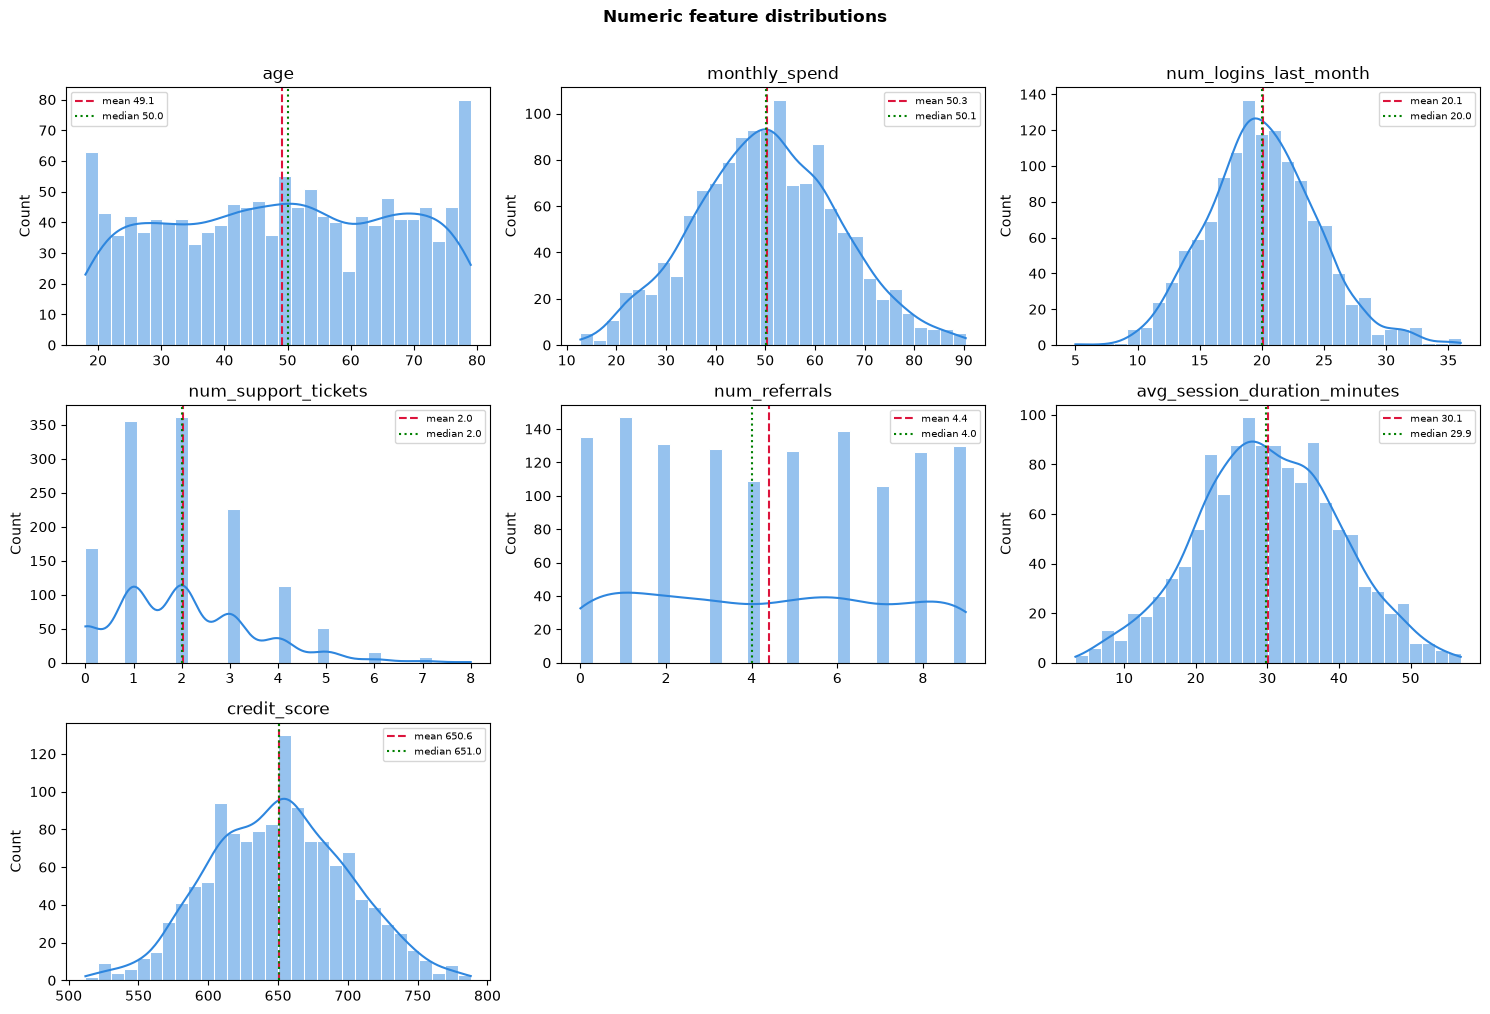

,mean,median,std,skew,kurtosis,min,max,shape
age,49.10,50.00,18.01,-0.03,-1.17,18.00,79.00,symmetric
monthly_spend,50.30,50.12,14.34,0.08,-0.24,12.77,90.39,symmetric
num_logins_last_month,20.08,20.00,4.39,0.26,0.31,5.00,36.00,symmetric
num_support_tickets,2.03,2.00,1.45,0.83,0.82,0.00,8.00,right-skewed
num_referrals,4.40,4.00,2.91,0.05,-1.26,0.00,9.00,symmetric
avg_session_duration_minutes,30.07,29.88,9.80,0.00,-0.24,3.20,57.01,symmetric
credit_score,650.64,651.00,48.98,0.05,-0.26,512.00,788.00,symmetric


In [16]:
# plot_cols = [ 'age', 'monthly_spend', 
                #    'avg_session_duration_minutes', 'credit_score']

plot_cols = ["age", "monthly_spend", "num_logins_last_month",
    "num_support_tickets", "num_referrals",
    "avg_session_duration_minutes", "credit_score"]

# plot_cols = CONTINUOUS + COUNT_COLS
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.ravel(), plot_cols):
    sns.histplot(df_clean[col].dropna(), kde=True, ax=ax, color="#2e86de", edgecolor="white", bins=30)
    ax.axvline(df_clean[col].mean(),   color="crimson", ls="--", lw=1.5, label=f"mean {df_clean[col].mean():.1f}")
    ax.axvline(df_clean[col].median(), color="green",   ls=":",  lw=1.5, label=f"median {df_clean[col].median():.1f}")
    ax.set(title=col, xlabel="")
    ax.legend(fontsize=7)
for ax in axes.ravel()[len(plot_cols):]:
    ax.axis("off")
plt.suptitle("Numeric feature distributions", fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

shape = pd.DataFrame({
    "mean":     df_clean[plot_cols].mean(),
    "median":   df_clean[plot_cols].median(),
    "std":      df_clean[plot_cols].std(),
    "skew":     df_clean[plot_cols].skew(),
    "kurtosis": df_clean[plot_cols].kurtosis(),
    "min":      df_clean[plot_cols].min(),
    "max":      df_clean[plot_cols].max(),
}).round(2)
shape["shape"] = np.where(shape["skew"].abs() < .5, "symmetric",
                   np.where(shape["skew"] > 0, "right-skewed", "left-skewed"))
display(shape)

In [17]:
df_clean.isnull().sum()

customer_id                       0
age                              90
gender                          105
subscription_type                89
signup_date                     102
last_active_date                 94
monthly_spend                    86
num_logins_last_month            87
num_support_tickets              87
is_auto_renew                    94
used_mobile_app                  89
num_referrals                   110
avg_session_duration_minutes    108
credit_score                     80
churned                         106
dtype: int64

In [18]:
df_clean['age'] = (df_clean['age'].fillna(df_clean['age'].mean())).astype(int)
df_clean['monthly_spend'] = df_clean['monthly_spend'].fillna(df_clean['monthly_spend'].mean())
df_clean['num_logins_last_month'] = (df_clean['num_logins_last_month'].fillna(df_clean['num_logins_last_month'].mean())).astype(int)
df_clean['num_referrals'] = (df_clean['num_referrals'].fillna(df_clean['num_referrals'].mean())).astype(int)
df_clean['avg_session_duration_minutes'] = df_clean['avg_session_duration_minutes'].fillna(df_clean['avg_session_duration_minutes'].mean())
df_clean['credit_score'] = (df_clean['credit_score'].fillna(df_clean['credit_score'].mean())).astype(int)

df_clean['num_support_tickets'] = (df_clean['num_support_tickets'].fillna(df_clean['num_support_tickets'].median()))

In [19]:
## dilling the gender using age group
## create age groups
bins = [18, 25, 35, 45, 55, 65, 80]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-80']

df_clean['age_group'] = pd.cut(df_clean['age'], bins=bins, labels=labels, right=False)
# find the most common gender in each age group
gender_by_age =  (df_clean.dropna(subset=['gender'])
      .groupby('age_group', observed=False)['gender']
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

print(gender_by_age)

## filling the missing gender values based on the most common gender in their respective age groups
df_clean['gender'] = df_clean['gender'].fillna(df_clean['age_group'].map(gender_by_age))

age_group
18-25    Female
26-35      Male
36-45      Male
46-55      Male
56-65      Male
66-80    Female
Name: gender, dtype: str


In [20]:
DATE_COLS = ["signup_date", "last_active_date"]

# Preserve the original dates and calculate the median observed tenure
date_source = df_clean[DATE_COLS].copy()
tenure = (date_source["last_active_date"] - date_source["signup_date"]).median()

# Impute missing signup dates using the known last-active date
m = df_clean["signup_date"].isna() & df_clean["last_active_date"].notna()
df_clean.loc[m, "signup_date"] = df_clean.loc[m, "last_active_date"] - tenure

# Impute missing last-active dates using the known signup date
m_l = df_clean["last_active_date"].isna() & df_clean["signup_date"].notna()
df_clean.loc[m_l, "last_active_date"] = df_clean.loc[m_l, "signup_date"] + tenure

# If both dates are missing, use the original median date for each column
for column in DATE_COLS:
    df_clean[column] = df_clean[column].fillna(date_source[column].median())

# Keep imputed dates within the original observed date ranges
for column in DATE_COLS:
    df_clean[column] = df_clean[column].clip(lower=date_source[column].min(), upper=date_source[column].max())

# Ensure the last-active date is not earlier than the signup date
bad = df_clean["last_active_date"] < df_clean["signup_date"]
df_clean.loc[bad, ["signup_date", "last_active_date"]] = df_clean.loc[bad, ["last_active_date", "signup_date"]].to_numpy()

# Calculate tenure in months
average_days_per_month = 365.25 / 12
df_clean["tenure_months"] = ((df_clean["last_active_date"] - df_clean["signup_date"]).dt.days / average_days_per_month).round(2)

In [21]:
df_clean.isnull().sum()

customer_id                       0
age                               0
gender                            0
subscription_type                89
signup_date                       0
last_active_date                  0
monthly_spend                     0
num_logins_last_month             0
num_support_tickets               0
is_auto_renew                    94
used_mobile_app                  89
num_referrals                     0
avg_session_duration_minutes      0
credit_score                      0
churned                         106
age_group                         0
tenure_months                     0
dtype: int64

## Filling the remaining columns

`subscription_type`, `is_auto_renew` and `used_mobile_app` are still incomplete, and `churned` is
the target. I fill the three feature columns here. I do not impute the target.

In [22]:
### Before I pick a fill rule, check whether these columns depend on anything I already know.
### If a grouping variable carries information I should fill within the group. If the table is
### flat, filling by group is just a global constant with extra steps.

from scipy.stats import chi2_contingency, mannwhitneyu

REMAINING_COLS = ['subscription_type', 'is_auto_renew', 'used_mobile_app']
CANDIDATE_GROUPS = ['age_group', 'gender', 'subscription_type', 'is_auto_renew', 'used_mobile_app']

dependency_report = []
for target_column in REMAINING_COLS:
    for group_column in CANDIDATE_GROUPS:
        if group_column == target_column:
            continue

        pair = df_clean[[target_column, group_column]].dropna()
        table = pd.crosstab(pair[group_column], pair[target_column])
        chi2, p_value, _, _ = chi2_contingency(table)
        n = table.to_numpy().sum()

        dependency_report.append({
            "missing_column": target_column,
            "candidate_group": group_column,
            "n": int(n),
            "chi2_p_value": round(p_value, 4),
            "cramers_v": round(np.sqrt(chi2 / (n * (min(table.shape) - 1))), 3),
        })

dependency_report = pd.DataFrame(dependency_report).sort_values("cramers_v", ascending=False)
display(dependency_report.reset_index(drop=True))

,missing_column,candidate_group,n,chi2_p_value,cramers_v
0,used_mobile_app,is_auto_renew,1212,0.0028,0.086
1,is_auto_renew,used_mobile_app,1212,0.0028,0.086
2,subscription_type,age_group,1299,0.1381,0.076
3,subscription_type,is_auto_renew,1213,0.0722,0.066
4,is_auto_renew,subscription_type,1213,0.0722,0.066
5,is_auto_renew,gender,1294,0.1728,0.052
6,used_mobile_app,age_group,1299,0.6258,0.052
7,subscription_type,used_mobile_app,1220,0.2729,0.046
8,used_mobile_app,subscription_type,1220,0.2729,0.046
9,is_auto_renew,age_group,1294,0.8074,0.042


The strongest association in that table is a Cramer's V of 0.086. Only one pair clears p = 0.05
(`is_auto_renew` against `used_mobile_app`, p = 0.003, listed twice because the table is
symmetric). That is one hit across twelve tests, which is what chance produces. Nothing predicts
these columns, so filling by group mode is not justified.

That leaves a global fill, and the mode is a poor fit here. All three columns are close to uniform:
`subscription_type` splits 35/33/32 and `is_auto_renew` splits 50/50. Assigning the mode to every
missing row would push one level about 4 percentage points above its observed share and invent a
majority the data does not show.

So I draw each gap from that column's own observed distribution with a fixed seed. This keeps the
marginal proportions intact. I also add a `*_was_missing` flag so I can find the filled rows
later.

In [23]:
### I fill from each column's own observed distribution with a fixed seed instead of using
### the mode, and flag the rows I filled.

rng = np.random.default_rng(42)
imputation_report = []

for column in REMAINING_COLS:
    observed = df_clean[column].dropna()
    proportions = observed.value_counts(normalize=True).sort_index()
    missing_mask = df_clean[column].isna()
    rows_missing = int(missing_mask.sum())
    mode_value = observed.mode().iloc[0]

    # Flag first, so I can still find the imputed rows once the column is full
    df_clean[f'{column}_was_missing'] = missing_mask.astype(int)
    df_clean.loc[missing_mask, column] = rng.choice(
        proportions.index.to_numpy(), size=rows_missing, p=proportions.to_numpy()
    )

    after_fill = df_clean[column].value_counts(normalize=True).sort_index()
    for level in proportions.index:
        mode_share = (observed.eq(level).sum() + (rows_missing if level == mode_value else 0)) / len(df_clean)
        imputation_report.append({
            "column": column,
            "level": level,
            "rows_filled": rows_missing,
            "observed_%": round(proportions[level] * 100, 1),
            "after_sampling_%": round(after_fill[level] * 100, 1),
            "if_mode_filled_%": round(mode_share * 100, 1),
        })

# The two flags are 0/1 indicators, so restore the integer type after filling
for column in ['is_auto_renew', 'used_mobile_app']:
    df_clean[column] = df_clean[column].astype(int)

imputation_report = pd.DataFrame(imputation_report)
imputation_report["sampling_drift_pp"] = (imputation_report["after_sampling_%"] - imputation_report["observed_%"]).round(1)
imputation_report["mode_drift_pp"] = (imputation_report["if_mode_filled_%"] - imputation_report["observed_%"]).round(1)

print("Distribution drift after filling (percentage points vs the observed share):")
print(f"  sampling: max {imputation_report['sampling_drift_pp'].abs().max():.1f} pp")
print(f"  mode:     max {imputation_report['mode_drift_pp'].abs().max():.1f} pp")
display(imputation_report)

Distribution drift after filling (percentage points vs the observed share):
  sampling: max 0.3 pp
  mode:     max 4.1 pp


,column,level,rows_filled,observed_%,after_sampling_%,if_mode_filled_%,sampling_drift_pp,mode_drift_pp
0,subscription_type,Basic,89,32.5,32.4,30.4,-0.1,-2.1
1,subscription_type,Free,89,35.2,35.2,39.3,0.0,4.1
2,subscription_type,Premium,89,32.3,32.3,30.3,0.0,-2.0
3,is_auto_renew,0.0,94,49.8,49.9,46.5,0.1,-3.3
4,is_auto_renew,1.0,94,50.2,50.1,53.5,-0.1,3.3
5,used_mobile_app,0.0,89,47.5,47.8,44.5,0.3,-3.0
6,used_mobile_app,1.0,89,52.5,52.2,55.5,-0.3,3.0


### The target column

`churned` is missing for 106 rows. Imputing a target means inventing the answer the model is meant
to learn, so I split those rows off and keep them for scoring instead of filling them. Everything
from here runs on the 1,282 labelled rows.

In [24]:
### I do not impute the target. Rows without a label are held out for scoring later.

labelled = df_clean[df_clean['churned'].notna()].copy()
labelled['churned'] = labelled['churned'].astype(int)

unlabelled = df_clean[df_clean['churned'].isna()].copy()

print(f"Rows with a churn label:    {len(labelled):,}")
print(f"Rows without a churn label: {len(unlabelled):,}  (held out, not imputed)")
print(f"Churn rate on labelled rows: {labelled['churned'].mean():.1%}")
print(f"Missing values left in the labelled features: "
      f"{int(labelled.drop(columns='churned').isnull().sum().sum())}")

Rows with a churn label:    1,282
Rows without a churn label: 106  (held out, not imputed)
Churn rate on labelled rows: 48.0%
Missing values left in the labelled features: 0


## Churn behaviour analysis

The frame is complete, so now I look at what separates a churner from a retained customer: the
target balance, the categorical splits, the age and subscription mix, the months between signup and
last activity, and the numeric features.

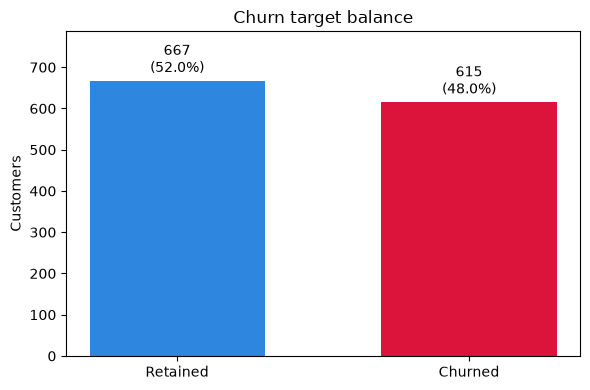

Churn rate:                       48.0%
Majority-class accuracy baseline: 52.0%
The classes are close to balanced, so accuracy is a weak metric here - ROC-AUC, precision, recall and F1 are the ones to read.


In [25]:
### Target balance. This sets the baseline any model has to beat.

fig, ax = plt.subplots(figsize=(6, 4))
target_counts = labelled['churned'].map({0: 'Retained', 1: 'Churned'}).value_counts()
bars = ax.bar(target_counts.index, target_counts.values, color=["#2e86de", "crimson"], width=.6)
ax.bar_label(bars, labels=[f"{v:,}\n({v / len(labelled):.1%})" for v in target_counts.values], padding=3)
ax.set(title="Churn target balance", xlabel="", ylabel="Customers")
ax.margins(y=.18)
plt.tight_layout(); plt.show()

overall_rate = labelled['churned'].mean()
print(f"Churn rate:                       {overall_rate:.1%}")
print(f"Majority-class accuracy baseline: {labelled['churned'].value_counts(normalize=True).max():.1%}")
print("The classes are close to balanced, so accuracy is a weak metric here - ROC-AUC, "
      "precision, recall and F1 are the ones to read.")

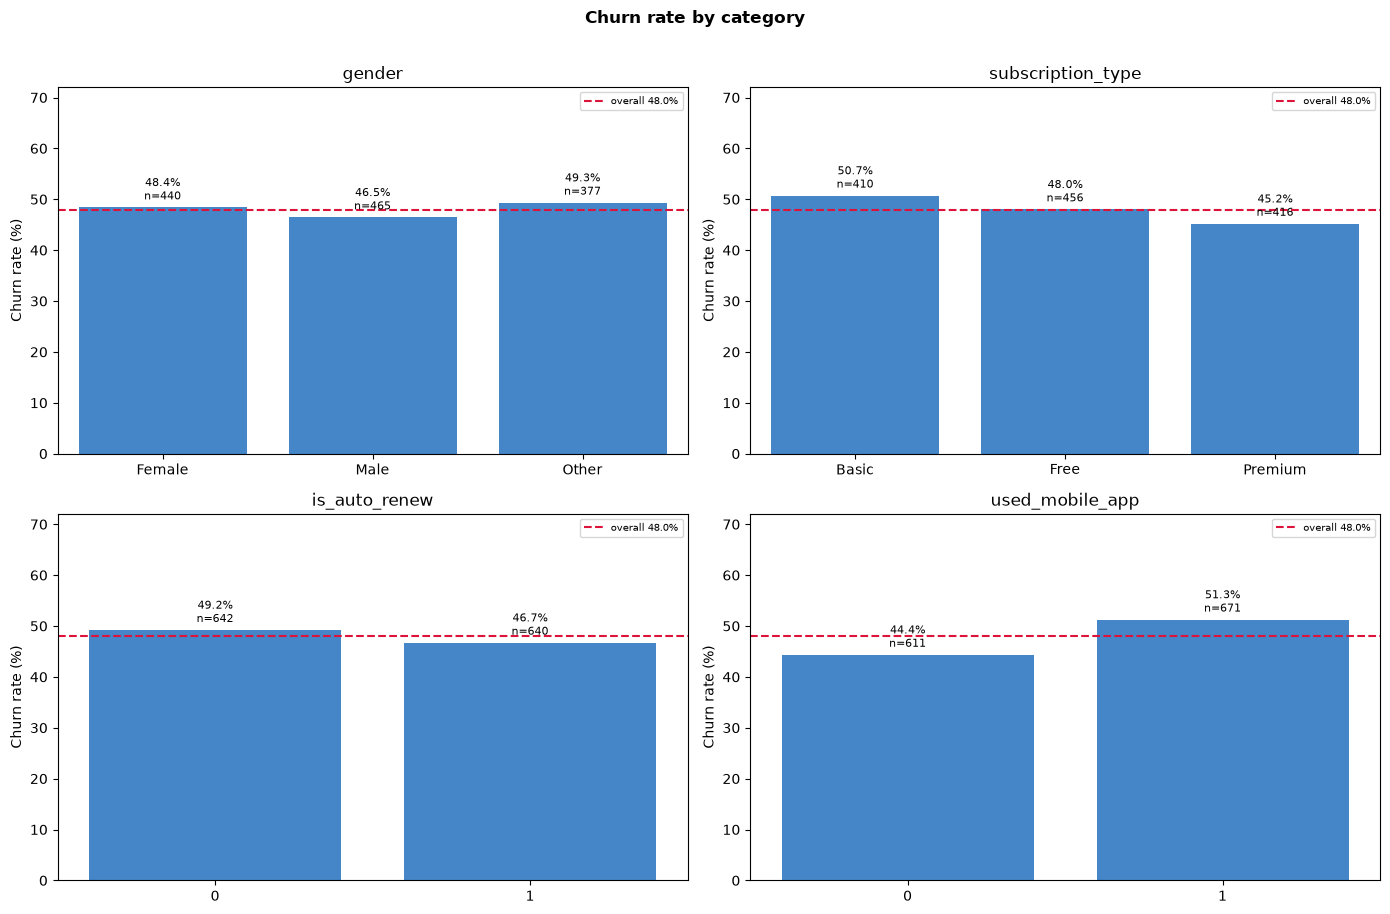

,feature,chi2_p_value,cramers_v,significant_5pct
0,used_mobile_app,0.0156,0.068,True
1,age_group,0.7253,0.047,False
2,subscription_type,0.2809,0.045,False
3,gender,0.6888,0.024,False
4,is_auto_renew,0.4004,0.023,False


In [26]:
### Churn rate inside each category, against the overall rate

CATEGORICAL_COLS = ['gender', 'subscription_type', 'is_auto_renew', 'used_mobile_app']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, column in zip(axes.ravel(), CATEGORICAL_COLS):
    grouped = labelled.groupby(column, observed=False)['churned'].agg(['count', 'mean'])
    sns.barplot(x=grouped.index.astype(str), y=grouped['mean'] * 100, color="#2e86de", ax=ax)
    ax.axhline(overall_rate * 100, color="crimson", ls="--", lw=1.5, label=f"overall {overall_rate:.1%}")
    ax.bar_label(ax.containers[0],
                 labels=[f"{m * 100:.1f}%\nn={c:,}" for c, m in zip(grouped['count'], grouped['mean'])],
                 padding=3, fontsize=8)
    ax.set(title=column, xlabel="", ylabel="Churn rate (%)", ylim=(0, 72))
    ax.legend(fontsize=7)
plt.suptitle("Churn rate by category", fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

### Chi-square tests how far each split is from independence. Cramer's V puts it on 0 to 1.
association_report = []
for column in CATEGORICAL_COLS + ['age_group']:
    table = pd.crosstab(labelled[column], labelled['churned'])
    chi2, p_value, _, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    association_report.append({
        "feature": column,
        "chi2_p_value": round(p_value, 4),
        "cramers_v": round(np.sqrt(chi2 / (n * (min(table.shape) - 1))), 3),
        "significant_5pct": p_value < 0.05,
    })

association_report = pd.DataFrame(association_report).sort_values("cramers_v", ascending=False)
display(association_report.reset_index(drop=True))

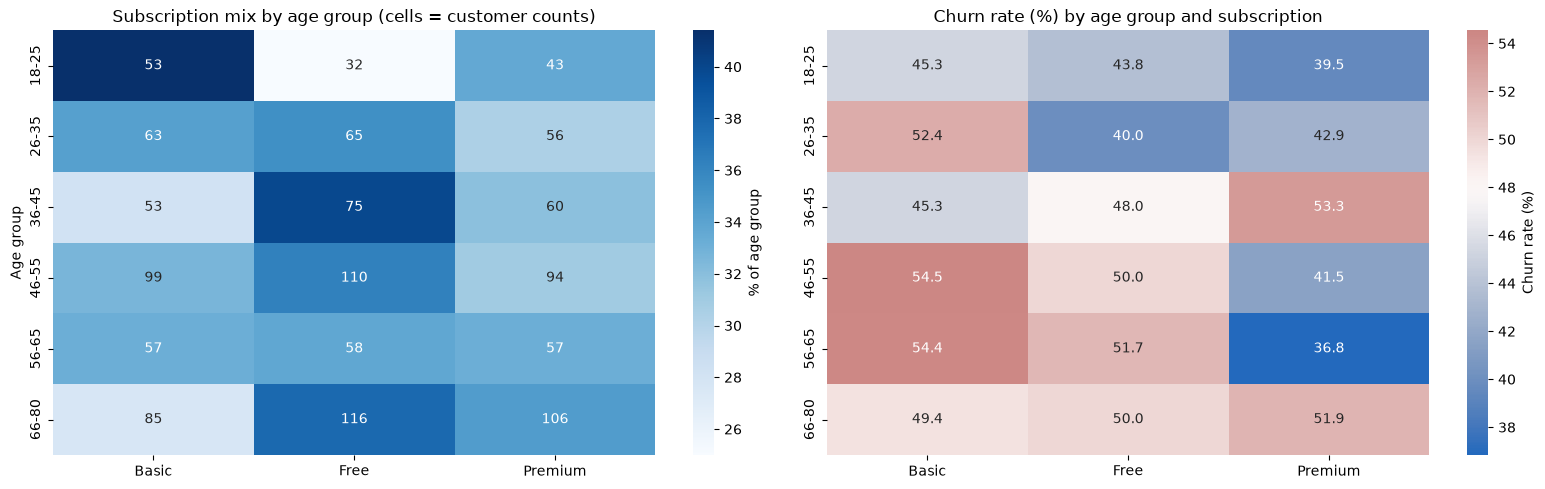

Customers per cell (small cells make their churn rates unstable):


subscription_type,Basic,Free,Premium
age_group,,,
18-25,53,32,43
26-35,63,65,56
36-45,53,75,60
46-55,99,110,94
56-65,57,58,57
66-80,85,116,106


In [27]:
### Age range against the subscription mix, and the churn rate inside each cell

subscription_mix = pd.crosstab(labelled['age_group'], labelled['subscription_type'])
mix_percent = pd.crosstab(labelled['age_group'], labelled['subscription_type'], normalize='index') * 100
cell_churn = pd.crosstab(labelled['age_group'], labelled['subscription_type'],
                         values=labelled['churned'], aggfunc='mean') * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(mix_percent, annot=subscription_mix, fmt="d", cmap="Blues",
            cbar_kws={"label": "% of age group"}, ax=axes[0])
axes[0].set(title="Subscription mix by age group (cells = customer counts)", xlabel="", ylabel="Age group")

sns.heatmap(cell_churn, annot=True, fmt=".1f", cmap="vlag", center=overall_rate * 100,
            cbar_kws={"label": "Churn rate (%)"}, ax=axes[1])
axes[1].set(title="Churn rate (%) by age group and subscription", xlabel="", ylabel="")
plt.tight_layout(); plt.show()

print("Customers per cell (small cells make their churn rates unstable):")
display(subscription_mix)

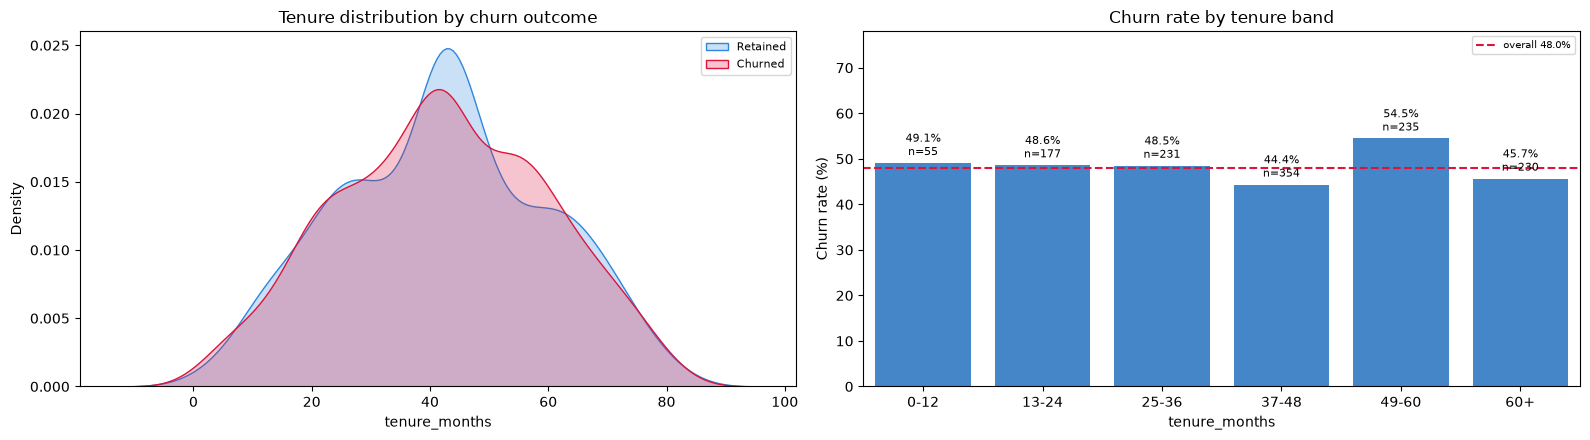

,count,mean,median,std
churned,,,,
0,667,42.10,42.35,17.57
1,615,42.15,42.35,17.59


Mann-Whitney p-value for tenure_months vs churn: 0.980


In [28]:
### Months between signup and last activity, compared against churn

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
for value, label, color in [(0, "Retained", "#2e86de"), (1, "Churned", "crimson")]:
    sns.kdeplot(labelled.loc[labelled['churned'] == value, 'tenure_months'],
                ax=axes[0], label=label, color=color, fill=True, alpha=.25)
axes[0].set(title="Tenure distribution by churn outcome", xlabel="tenure_months", ylabel="Density")
axes[0].legend(fontsize=8)

tenure_bands = pd.cut(labelled['tenure_months'], bins=[0, 12, 24, 36, 48, 60, np.inf],
                      labels=['0-12', '13-24', '25-36', '37-48', '49-60', '60+'], include_lowest=True)
band_summary = labelled.groupby(tenure_bands, observed=False)['churned'].agg(['count', 'mean'])

sns.barplot(x=band_summary.index.astype(str), y=band_summary['mean'] * 100, color="#2e86de", ax=axes[1])
axes[1].axhline(overall_rate * 100, color="crimson", ls="--", lw=1.5, label=f"overall {overall_rate:.1%}")
axes[1].bar_label(axes[1].containers[0],
                  labels=[f"{m * 100:.1f}%\nn={c:,}" for c, m in zip(band_summary['count'], band_summary['mean'])],
                  padding=3, fontsize=8)
axes[1].set(title="Churn rate by tenure band", xlabel="tenure_months", ylabel="Churn rate (%)", ylim=(0, 78))
axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

display(labelled.groupby('churned')['tenure_months'].agg(['count', 'mean', 'median', 'std']).round(2))
tenure_p = mannwhitneyu(labelled.loc[labelled['churned'] == 0, 'tenure_months'],
                        labelled.loc[labelled['churned'] == 1, 'tenure_months']).pvalue
print(f"Mann-Whitney p-value for tenure_months vs churn: {tenure_p:.3f}")

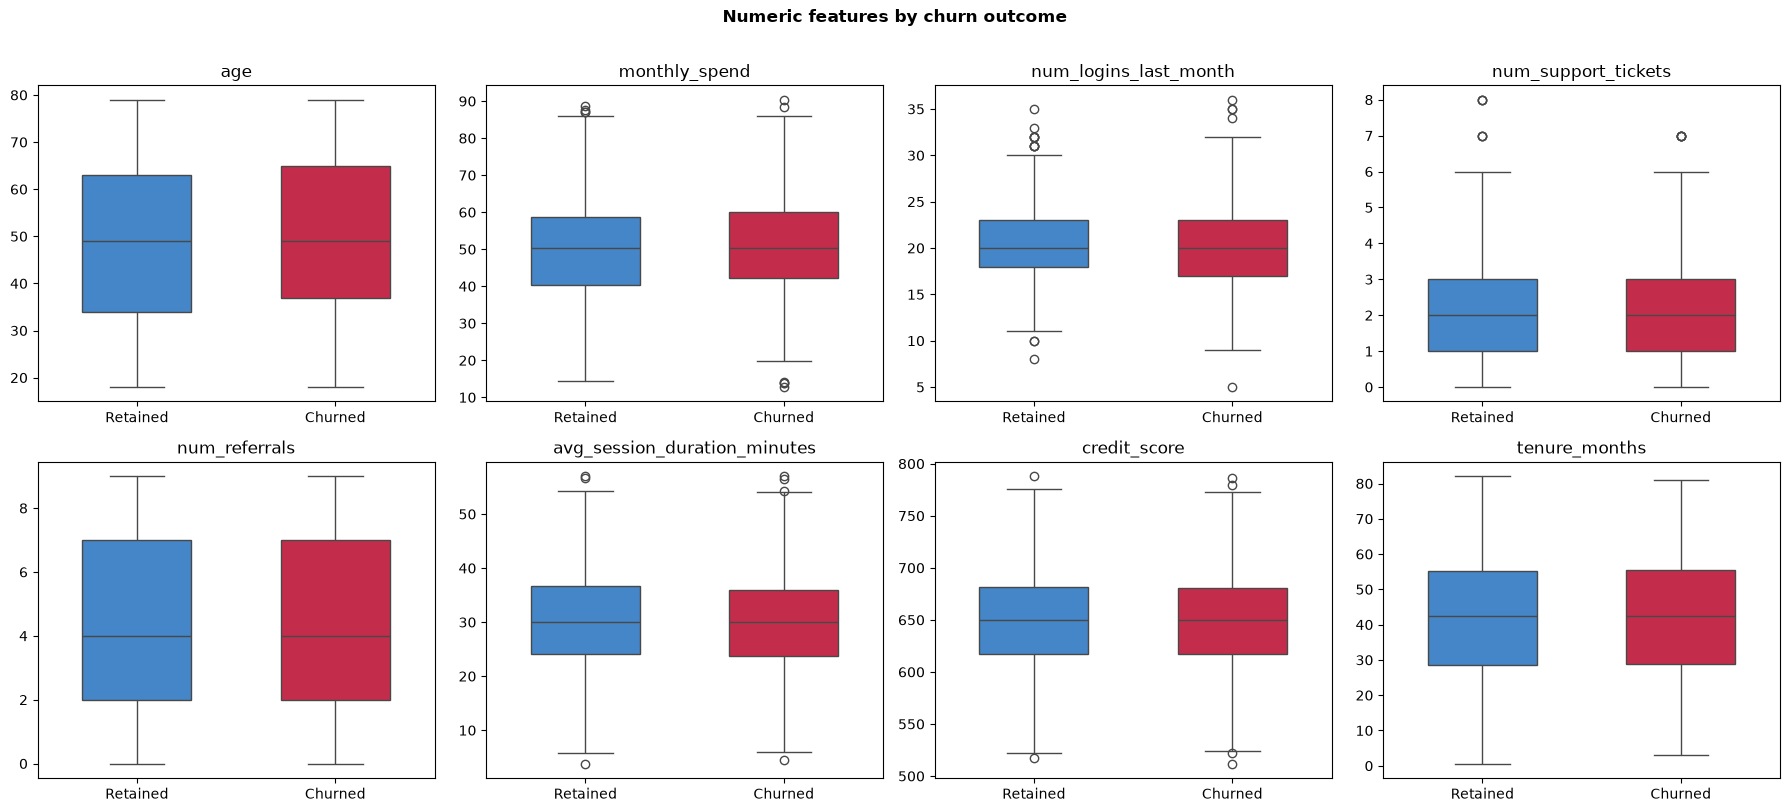

,feature,retained_mean,churned_mean,std_mean_difference,mann_whitney_p
0,monthly_spend,49.68,50.89,0.087,0.1362
1,age,48.53,49.85,0.076,0.1881
2,avg_session_duration_minutes,30.29,29.89,-0.042,0.3553
3,credit_score,649.84,651.20,0.029,0.5751
4,num_referrals,4.41,4.34,-0.024,0.6710
5,num_logins_last_month,20.08,20.03,-0.010,0.5046
6,num_support_tickets,2.02,2.03,0.005,0.7162
7,tenure_months,42.10,42.15,0.003,0.9801


In [29]:
### Numeric features split by outcome, with an effect size for each one

NUMERIC_EDA_COLS = ["age", "monthly_spend", "num_logins_last_month", "num_support_tickets",
                    "num_referrals", "avg_session_duration_minutes", "credit_score", "tenure_months"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, column in zip(axes.ravel(), NUMERIC_EDA_COLS):
    sns.boxplot(data=labelled, x='churned', y=column, hue='churned',
                palette=["#2e86de", "crimson"], legend=False, width=.55, ax=ax)
    ax.set(title=column, xlabel="", ylabel="")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Retained", "Churned"])
plt.suptitle("Numeric features by churn outcome", fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

### Standardised mean difference, where |SMD| below 0.2 is a negligible gap, plus a
### distribution-free test
separation_report = []
for column in NUMERIC_EDA_COLS:
    retained = labelled.loc[labelled['churned'] == 0, column]
    churned = labelled.loc[labelled['churned'] == 1, column]
    pooled_sd = np.sqrt(((len(retained) - 1) * retained.var(ddof=1) +
                         (len(churned) - 1) * churned.var(ddof=1)) /
                        (len(retained) + len(churned) - 2))
    separation_report.append({
        "feature": column,
        "retained_mean": round(retained.mean(), 2),
        "churned_mean": round(churned.mean(), 2),
        "std_mean_difference": round((churned.mean() - retained.mean()) / pooled_sd, 3),
        "mann_whitney_p": round(mannwhitneyu(retained, churned).pvalue, 4),
    })

separation_report = pd.DataFrame(separation_report)
separation_report = separation_report.reindex(
    separation_report['std_mean_difference'].abs().sort_values(ascending=False).index)
display(separation_report.reset_index(drop=True))

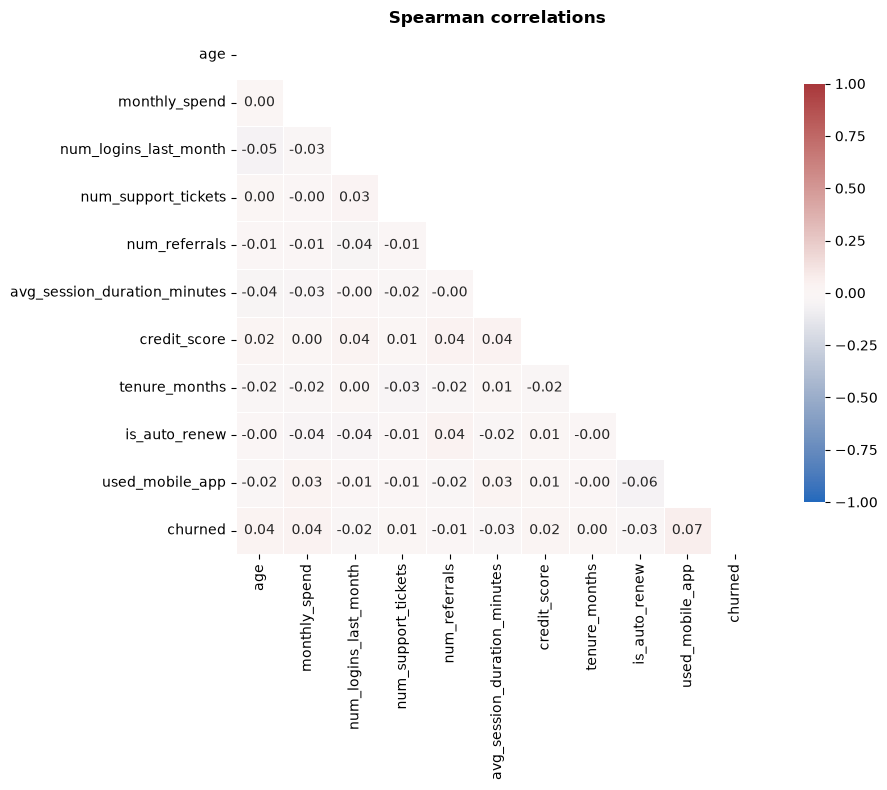

,correlation_with_churn
used_mobile_app,0.069
monthly_spend,0.042
age,0.037
avg_session_duration_minutes,-0.026
is_auto_renew,-0.025
num_logins_last_month,-0.019
credit_score,0.016
num_referrals,-0.012
num_support_tickets,0.010
tenure_months,0.001


In [30]:
### Correlations between the features, and against the target

correlation_cols = NUMERIC_EDA_COLS + ['is_auto_renew', 'used_mobile_app', 'churned']
spearman_corr = labelled[correlation_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(spearman_corr, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1, annot=True,
            fmt=".2f", square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Spearman correlations", fontweight="bold")
plt.tight_layout(); plt.show()

churn_correlation = spearman_corr['churned'].drop('churned')
churn_correlation = churn_correlation.reindex(churn_correlation.abs().sort_values(ascending=False).index)
display(churn_correlation.round(3).to_frame("correlation_with_churn"))

### What the EDA shows

The target is close to balanced, 48.0% churned against 52.0% retained across 1,282 labelled
customers. That means the majority-class baseline is already 52.0% accuracy, so accuracy on its own
will not tell me whether a model works.

Past that, no feature separates the two groups.

The categorical splits are flat. Every Cramer's V is 0.068 or below. `used_mobile_app` is the only
one reaching significance (p = 0.016), and that is one hit across five tests, which is the rate
chance produces. The direction is also backwards: app users churn more (51.3% against 44.4%). I
would not build a campaign on that.

The numeric gaps are negligible. The largest standardised mean difference is 0.087 for
`monthly_spend`, and a gap is usually only worth noting above 0.2. The smallest Mann-Whitney
p-value across all eight features is 0.14.

Tenure does not matter, which is the part I did not expect. Months between signup and last activity
average 42.10 for retained customers and 42.15 for churners (p = 0.98). Tenure and inactivity are
normally the strongest churn predictors in a subscription business. Here they are flat. The swing
across tenure bands (44.4% at 37-48 months against 54.5% at 49-60) is not monotonic, so I read it
as noise across a few hundred customers rather than a trend.

All correlations with the target are below 0.07.

The age and subscription heatmap shows the only visible structure in the data. The 18-25 group
skews towards Basic (41.4%) and away from Free (25.0%), while every other age band sits near a
34/36/31 split. That is a difference in mix between age groups, not a churn driver, because the
churn rates inside those cells stay flat.

This looks like a dataset with no learnable churn signal. I test that with models in the next
section rather than assuming it.

## Feature engineering

The raw columns describe a customer at one point in time. The features below turn them into the
quantities a churn model can actually use: how long since I last saw the customer, how intensely
they use the product, what they are worth, and how committed they are.

I use a snapshot date of 2025-01-01 as "today". The last observed activity is 2024-12-31, and
having a fixed reference date is what makes the recency features possible.

In [31]:
### I build the features on the full cleaned frame so the unlabelled rows can be scored
### later with exactly the same columns.

SNAPSHOT_DATE = pd.Timestamp("2025-01-01")

df_features = df_clean.copy()

## Recency and lifecycle: how long since I last saw them, and how long they have existed
df_features['inactivity_days']  = (SNAPSHOT_DATE - df_features['last_active_date']).dt.days
df_features['account_age_days'] = (SNAPSHOT_DATE - df_features['signup_date']).dt.days
df_features['tenure_days']      = (df_features['last_active_date'] - df_features['signup_date']).dt.days
df_features['dormancy_ratio']   = df_features['inactivity_days'] / df_features['account_age_days']
df_features['signup_year']      = df_features['signup_date'].dt.year
df_features['signup_month']     = df_features['signup_date'].dt.month

## Intensity: I divide the raw counts by exposure so a long-tenured customer is comparable
df_features['spend_per_login']         = df_features['monthly_spend'] / df_features['num_logins_last_month']
df_features['minutes_per_login']       = df_features['avg_session_duration_minutes'] / df_features['num_logins_last_month']
df_features['total_session_minutes']   = df_features['avg_session_duration_minutes'] * df_features['num_logins_last_month']
df_features['logins_per_tenure_month'] = df_features['num_logins_last_month'] / df_features['tenure_months']
df_features['tickets_per_login']       = df_features['num_support_tickets'] / df_features['num_logins_last_month']

## Value and commitment
df_features['lifetime_value_est']  = df_features['monthly_spend'] * df_features['tenure_months']
df_features['has_support_contact'] = (df_features['num_support_tickets'] > 0).astype(int)
df_features['is_referrer']         = (df_features['num_referrals'] > 0).astype(int)
df_features['subscription_rank']   = df_features['subscription_type'].map({'Free': 0, 'Basic': 1, 'Premium': 2})
df_features['is_premium']          = (df_features['subscription_type'] == 'Premium').astype(int)
df_features['digital_engagement']  = df_features['used_mobile_app'] * df_features['num_logins_last_month']
df_features['low_commitment']      = ((df_features['is_auto_renew'] == 0) &
                                      (df_features['subscription_type'] == 'Free')).astype(int)

## Log transforms for the money and duration columns, which are right-skewed
for column in ['monthly_spend', 'avg_session_duration_minutes', 'lifetime_value_est',
               'total_session_minutes', 'spend_per_login']:
    df_features[f'log_{column}'] = np.log1p(df_features[column])

engineered = [c for c in df_features.columns if c not in df_clean.columns]
print(f"Engineered {len(engineered)} new features:")
print(", ".join(engineered))
print(f"\nNo infinities or nulls introduced: "
      f"{not np.isinf(df_features[engineered].to_numpy(dtype=float)).any() and df_features[engineered].isnull().sum().sum() == 0}")

Engineered 23 new features:
inactivity_days, account_age_days, tenure_days, dormancy_ratio, signup_year, signup_month, spend_per_login, minutes_per_login, total_session_minutes, logins_per_tenure_month, tickets_per_login, lifetime_value_est, has_support_contact, is_referrer, subscription_rank, is_premium, digital_engagement, low_commitment, log_monthly_spend, log_avg_session_duration_minutes, log_lifetime_value_est, log_total_session_minutes, log_spend_per_login

No infinities or nulls introduced: True


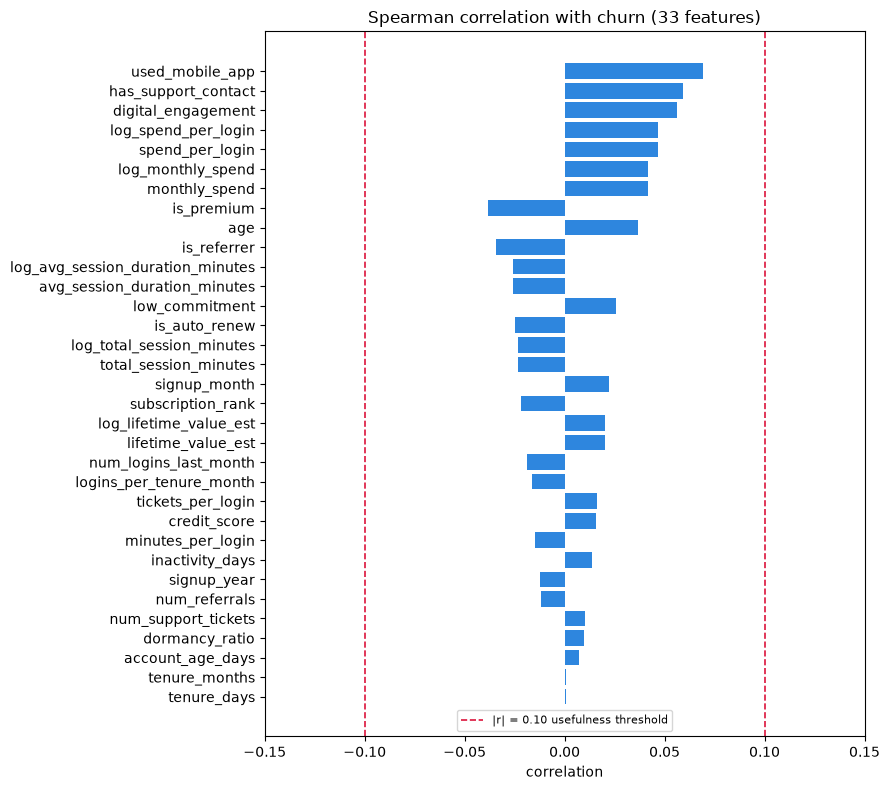

Model features: 36  |  training rows: 1,282  |  rows to score: 106
Strongest |correlation| with churn: 0.069 (used_mobile_app)
Features clearing |r| = 0.10: 0 of 33


,correlation_with_churn
used_mobile_app,0.069
has_support_contact,0.059
digital_engagement,0.056
log_spend_per_login,0.047
spend_per_login,0.047
log_monthly_spend,0.042
monthly_spend,0.042
is_premium,-0.039
age,0.037
is_referrer,-0.034


In [32]:
### Do any of the features I engineered carry more signal than the raw ones?

NUMERIC_FEATURES = [
    'age', 'monthly_spend', 'num_logins_last_month', 'num_support_tickets', 'num_referrals',
    'avg_session_duration_minutes', 'credit_score', 'tenure_months', 'tenure_days',
    'inactivity_days', 'account_age_days', 'dormancy_ratio', 'signup_year', 'signup_month',
    'spend_per_login', 'minutes_per_login', 'total_session_minutes', 'lifetime_value_est',
    'logins_per_tenure_month', 'tickets_per_login', 'subscription_rank',
    'log_monthly_spend', 'log_avg_session_duration_minutes', 'log_lifetime_value_est',
    'log_total_session_minutes', 'log_spend_per_login',
]
BINARY_FEATURES = ['is_auto_renew', 'used_mobile_app', 'has_support_contact', 'is_referrer',
                   'is_premium', 'digital_engagement', 'low_commitment']
CATEGORICAL_FEATURES = ['gender', 'subscription_type', 'age_group']

MODEL_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

model_frame = df_features[df_features['churned'].notna()].copy()
model_frame['churned'] = model_frame['churned'].astype(int)
scoring_frame = df_features[df_features['churned'].isna()].copy()

feature_screen = model_frame[NUMERIC_FEATURES + BINARY_FEATURES + ['churned']].corr(method='spearman')['churned'].drop('churned')
feature_screen = feature_screen.reindex(feature_screen.abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9, 8))
colors = ["crimson" if abs(v) >= 0.10 else "#2e86de" for v in feature_screen.values]
ax.barh(feature_screen.index[::-1], feature_screen.values[::-1], color=colors[::-1])
ax.axvline(0.10, color="crimson", ls="--", lw=1.2, label="|r| = 0.10 usefulness threshold")
ax.axvline(-0.10, color="crimson", ls="--", lw=1.2)
ax.set(title=f"Spearman correlation with churn ({len(feature_screen)} features)", xlabel="correlation", xlim=(-0.15, 0.15))
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"Model features: {len(MODEL_FEATURES)}  |  training rows: {len(model_frame):,}  |  rows to score: {len(scoring_frame):,}")
print(f"Strongest |correlation| with churn: {feature_screen.abs().max():.3f} ({feature_screen.abs().idxmax()})")
print(f"Features clearing |r| = 0.10: {(feature_screen.abs() >= 0.10).sum()} of {len(feature_screen)}")
display(feature_screen.head(10).round(3).to_frame("correlation_with_churn"))

Not one engineered feature clears |r| = 0.10, including `inactivity_days` and `dormancy_ratio`,
which are usually the dominant predictors in a subscription business. The feature set is built
correctly and it is the one I would give a model. It just has nothing to work with.

A correlation screen only catches linear relationships, so it would miss a non-linear or
interaction effect. The next section checks for those with models.

## Model training and evaluation

I train six models on the same split, the same folds and the same preprocessing:

| Model | What it can find that the others cannot |
|---|---|
| Logistic regression (baseline) | A monotone linear relationship. Everything else has to beat this. |
| Decision tree | Axis-aligned rules, and interactions between two or three features. |
| K-nearest neighbours | Local structure, churners clustered together with no global rule. |
| Random forest | Many decorrelated trees averaged, so it finds interactions without one tree's variance. |
| Gradient boosting | Trees fitted in sequence, each correcting the last. Strongest on subtle additive effects. |
| XGBoost | The same idea, regularised, and better at exploiting weak noisy signal. |

Logistic regression is the baseline on purpose. It is the simplest thing that could work, it is
interpretable, and it is fast, so anything more complex has to earn its place by beating it. The
six together cover the ways a churn signal could hide from a linear model: non-linearity,
interactions and local clustering. If all six land at the same score, the problem is in the data
and not in my choice of model. That is why I run six instead of one.

I then tune the best model by cross-validated ROC-AUC with Optuna, 60 trials of Bayesian search
over its own hyperparameter space. That tests whether the flat result is just untuned defaults.

For evaluation I use stratified 5-fold cross-validation on the training set for both model
selection and tuning, and a held-out 20% test set that I touch once at the end. ROC-AUC is my
headline metric because the classes are near balanced and it does not depend on a threshold.
Precision, recall, F1 and PR-AUC sit alongside it. The decision threshold is a separate choice and
I make it after tuning, from out-of-fold predictions, in its own section.

In [33]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score, recall_score,
                             f1_score, accuracy_score, confusion_matrix, roc_curve,
                             precision_recall_curve, classification_report)

X = model_frame[MODEL_FEATURES]
y = model_frame['churned']

### I make the split once, stratified so both sides keep the same churn rate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Scaling matters for the linear model and KNN needs it, since KNN measures distances.
### One-hot for the three categoricals. I keep both inside the pipeline so the folds cannot
### leak into each other, and every model gets a fresh clone of it.
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC_FEATURES + BINARY_FEATURES),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CATEGORICAL_FEATURES),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train: {len(X_train):,} rows ({y_train.mean():.1%} churn)")
print(f"Test:  {len(X_test):,} rows ({y_test.mean():.1%} churn)")

Train: 1,025 rows (48.0% churn)
Test:  257 rows (47.9% churn)


,model,cv_roc_auc_mean,cv_roc_auc_std,test_roc_auc,test_pr_auc,accuracy,precision,recall,f1
0,Gradient boosting,0.524,0.016,0.463,0.458,0.494,0.470,0.439,0.454
1,XGBoost,0.524,0.035,0.451,0.451,0.463,0.437,0.423,0.430
2,Random forest,0.515,0.027,0.445,0.429,0.451,0.420,0.382,0.400
3,K-nearest neighbours,0.512,0.047,0.533,0.503,0.560,0.540,0.545,0.543
4,Logistic regression (baseline),0.500,0.020,0.471,0.453,0.475,0.433,0.317,0.366
5,Decision tree,0.498,0.020,0.506,0.496,0.494,0.459,0.317,0.375


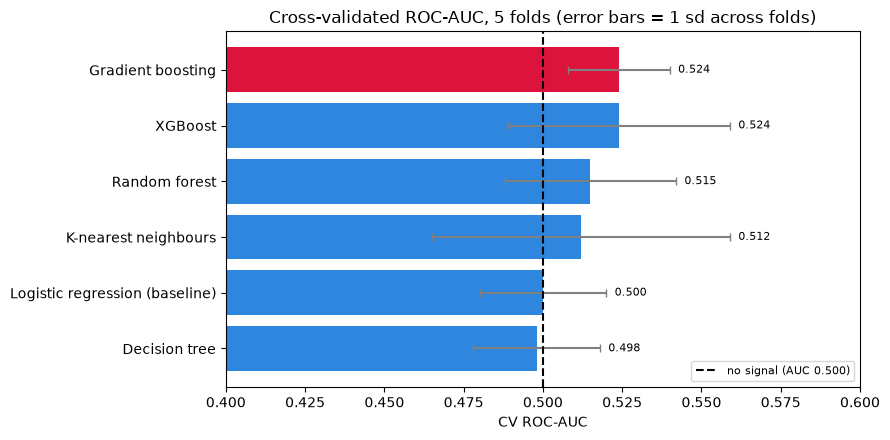

Best cross-validated model: Gradient boosting (0.524 +/- 0.016)
Logistic regression baseline: 0.500
Spread across all six models: 0.026 AUC, against a fold-to-fold sd of up to 0.047
Rank agreement between the CV ordering and the test ordering: -0.64

A model with no signal scores ROC-AUC 0.50. All six sit within one cross-validation standard deviation of that, and none pulls clear of the logistic baseline.


In [34]:
### Six models on identical folds and identical preprocessing. Logistic regression is my
### baseline because it is the simplest thing that could work, so anything more complex has to
### beat it. The other five cover the ways a churn signal could hide from a linear model:
### axis-aligned rules (decision tree), local similarity (KNN), and three ensembles that build
### interactions on their own (random forest, gradient boosting, XGBoost).

candidate_models = {
    'Logistic regression (baseline)': LogisticRegression(max_iter=2000, C=1.0, random_state=42),
    'Decision tree':                  DecisionTreeClassifier(max_depth=5, min_samples_leaf=20,
                                                             random_state=42),
    'K-nearest neighbours':           KNeighborsClassifier(n_neighbors=25),
    'Random forest':                  RandomForestClassifier(n_estimators=400, min_samples_leaf=5,
                                                             random_state=42, n_jobs=-1),
    'Gradient boosting':              GradientBoostingClassifier(random_state=42),
    'XGBoost':                        XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                                                    subsample=0.8, colsample_bytree=0.8,
                                                    eval_metric='logloss', random_state=42, n_jobs=-1),
}

fitted_models = {}
evaluation = []

for name, estimator in candidate_models.items():
    pipeline = Pipeline([('prep', clone(preprocessor)), ('model', estimator)])

    ### I select on the training folds only. The test set is scored once, at the end.
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline

    probabilities = pipeline.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)

    evaluation.append({
        'model': name,
        'cv_roc_auc_mean': round(cv_scores.mean(), 3),
        'cv_roc_auc_std': round(cv_scores.std(), 3),
        'test_roc_auc': round(roc_auc_score(y_test, probabilities), 3),
        'test_pr_auc': round(average_precision_score(y_test, probabilities), 3),
        'accuracy': round(accuracy_score(y_test, predictions), 3),
        'precision': round(precision_score(y_test, predictions, zero_division=0), 3),
        'recall': round(recall_score(y_test, predictions, zero_division=0), 3),
        'f1': round(f1_score(y_test, predictions, zero_division=0), 3),
    })

evaluation = pd.DataFrame(evaluation).sort_values('cv_roc_auc_mean', ascending=False).reset_index(drop=True)
display(evaluation)

### I take the model with the best cross-validated ROC-AUC forward to tuning
best_model_name = evaluation.loc[0, 'model']
baseline_cv = evaluation.loc[evaluation['model'] == 'Logistic regression (baseline)', 'cv_roc_auc_mean'].iloc[0]

fig, ax = plt.subplots(figsize=(9, 4.5))
order = evaluation.iloc[::-1]
bars = ax.barh(order['model'], order['cv_roc_auc_mean'],
               xerr=order['cv_roc_auc_std'], capsize=3, ecolor="gray",
               color=["crimson" if m == best_model_name else "#2e86de" for m in order['model']])
ax.axvline(0.5, color="black", ls="--", lw=1.5, label="no signal (AUC 0.500)")
ax.bar_label(bars, fmt="%.3f", padding=6, fontsize=8)
ax.set(title="Cross-validated ROC-AUC, 5 folds (error bars = 1 sd across folds)",
       xlabel="CV ROC-AUC", xlim=(0.40, 0.60))
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

spread = evaluation['cv_roc_auc_mean'].max() - evaluation['cv_roc_auc_mean'].min()
print(f"Best cross-validated model: {best_model_name} "
      f"({evaluation.loc[0, 'cv_roc_auc_mean']:.3f} +/- {evaluation.loc[0, 'cv_roc_auc_std']:.3f})")
print(f"Logistic regression baseline: {baseline_cv:.3f}")
print(f"Spread across all six models: {spread:.3f} AUC, against a fold-to-fold "
      f"sd of up to {evaluation['cv_roc_auc_std'].max():.3f}")
rank_agreement_cv_test = evaluation['cv_roc_auc_mean'].corr(evaluation['test_roc_auc'], method='spearman')
print(f"Rank agreement between the CV ordering and the test ordering: {rank_agreement_cv_test:+.2f}")
print("\nA model with no signal scores ROC-AUC 0.50. All six sit within one cross-validation "
      "standard deviation of that, and none pulls clear of the logistic baseline.")

### Which model to tune, and what the comparison already says

Gradient boosting takes the top cross-validated score at 0.524, so that is the one I carry into
tuning. The table is more useful for what it fails to show.

The top two are exactly tied. Gradient boosting and XGBoost both score 0.524, so picking a winner
between them is a coin toss decided in the third decimal place.

All six models span 0.026 of AUC, from 0.498 to 0.524, while the fold-to-fold standard deviation
inside a single model reaches 0.047. The gap between the best and worst model is smaller than the
noise inside one of them, so they are tied in any sense that matters.

Nothing pulls clear of the baseline. Logistic regression cross-validates at 0.500, exactly the
no-signal value. The three families that find interactions on their own (random forest, gradient
boosting, XGBoost) found nothing a straight line missed, and KNN found no local clustering. If
flexible models cannot beat a linear baseline, there is no non-linear structure to find.

The decision tree scores below 0.500, at 0.498. A tree that cannot find one useful split is saying
directly that no threshold on any feature separates churners from retained customers.

The cross-validation ranking does not survive to the test set. Rank agreement between the two
orderings is -0.64, so the ordering almost exactly inverts. Gradient boosting is first in
cross-validation and second to last on test at 0.463, while KNN is fourth in cross-validation and
first on test at 0.533. A real ranking is stable. This one flips, which tells me it is driven by
which rows happened to land in which fold.

So picking a winner from this table is already picking on noise. I run the tuning step anyway,
because "you did not tune it" is the obvious objection to a flat result and it deserves an
answer.

,version,cv_roc_auc,test_roc_auc,test_pr_auc,accuracy,precision,recall,f1
0,Gradient boosting (default),0.524,0.463,0.458,0.494,0.470,0.439,0.454
1,"Gradient boosting (Optuna, 60 trials)",0.539,0.453,0.445,0.444,0.422,0.439,0.430


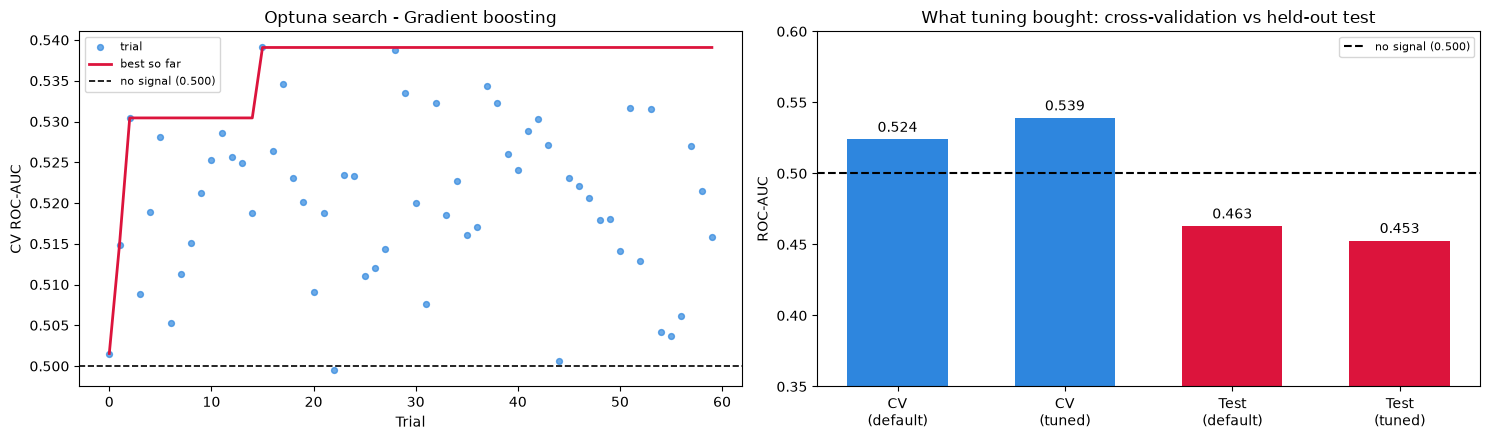

Best parameters found for Gradient boosting:
  n_estimators: 250
  learning_rate: 0.06779801741589847
  max_depth: 5
  min_samples_leaf: 7
  subsample: 0.6606749375990563

Cross-validated ROC-AUC: 0.524 -> 0.539 (+0.015)
Held-out test ROC-AUC:   0.463 -> 0.453 (-0.010)
Trial scores ranged 0.499 to 0.539 (median 0.521)


In [35]:
### I only tune the winner. The search runs against the same 5-fold cross-validation on the
### training set, so the test set stays untouched and I can compare the tuned model to the
### untuned one on the same terms.

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def suggest_estimator(trial, name):
    """Hyperparameter space for whichever of the six models won above."""
    if name.startswith('Logistic'):
        return LogisticRegression(
            C=trial.suggest_float('C', 1e-3, 1e2, log=True),
            class_weight=trial.suggest_categorical('class_weight', [None, 'balanced']),
            penalty='l2', solver='lbfgs', max_iter=2000, random_state=42)

    if name.startswith('Decision'):
        return DecisionTreeClassifier(
            max_depth=trial.suggest_int('max_depth', 2, 12),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 5, 80),
            min_samples_split=trial.suggest_int('min_samples_split', 2, 60),
            criterion=trial.suggest_categorical('criterion', ['gini', 'entropy']),
            ccp_alpha=trial.suggest_float('ccp_alpha', 1e-5, 1e-1, log=True),
            random_state=42)

    if name.startswith('K-nearest'):
        return KNeighborsClassifier(
            n_neighbors=trial.suggest_int('n_neighbors', 3, 120),
            weights=trial.suggest_categorical('weights', ['uniform', 'distance']),
            p=trial.suggest_categorical('p', [1, 2]))

    if name.startswith('Random'):
        return RandomForestClassifier(
            n_estimators=trial.suggest_int('n_estimators', 200, 800, step=100),
            max_depth=trial.suggest_int('max_depth', 2, 16),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 40),
            max_features=trial.suggest_float('max_features', 0.1, 1.0),
            random_state=42, n_jobs=-1)

    if name.startswith('Gradient'):
        return GradientBoostingClassifier(
            n_estimators=trial.suggest_int('n_estimators', 50, 500, step=50),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            max_depth=trial.suggest_int('max_depth', 2, 6),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 40),
            subsample=trial.suggest_float('subsample', 0.6, 1.0),
            random_state=42)

    return XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 800, step=50),
        max_depth=trial.suggest_int('max_depth', 2, 8),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.4, 1.0),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 20),
        gamma=trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 50.0, log=True),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        eval_metric='logloss', random_state=42, n_jobs=-1)


def objective(trial):
    pipeline = Pipeline([('prep', clone(preprocessor)),
                         ('model', suggest_estimator(trial, best_model_name))])
    return cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1).mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=60, show_progress_bar=False)

### Rebuild the winning configuration and fit it on the full training set
final_model = Pipeline([('prep', clone(preprocessor)),
                        ('model', suggest_estimator(optuna.trial.FixedTrial(study.best_params),
                                                    best_model_name))])
final_model.fit(X_train, y_train)

tuned_probabilities = final_model.predict_proba(X_test)[:, 1]
tuned_predictions = (tuned_probabilities >= 0.5).astype(int)

untuned = evaluation.loc[evaluation['model'] == best_model_name].iloc[0]
tuning_comparison = pd.DataFrame([
    {'version': f'{best_model_name} (default)',
     'cv_roc_auc': untuned['cv_roc_auc_mean'], 'test_roc_auc': untuned['test_roc_auc'],
     'test_pr_auc': untuned['test_pr_auc'], 'accuracy': untuned['accuracy'],
     'precision': untuned['precision'], 'recall': untuned['recall'], 'f1': untuned['f1']},
    {'version': f'{best_model_name} (Optuna, {len(study.trials)} trials)',
     'cv_roc_auc': round(study.best_value, 3),
     'test_roc_auc': round(roc_auc_score(y_test, tuned_probabilities), 3),
     'test_pr_auc': round(average_precision_score(y_test, tuned_probabilities), 3),
     'accuracy': round(accuracy_score(y_test, tuned_predictions), 3),
     'precision': round(precision_score(y_test, tuned_predictions, zero_division=0), 3),
     'recall': round(recall_score(y_test, tuned_predictions, zero_division=0), 3),
     'f1': round(f1_score(y_test, tuned_predictions, zero_division=0), 3)},
])
display(tuning_comparison)

### What the search actually did: the CV score climbs and the test score does not follow
trial_values = np.array([t.value for t in study.trials if t.value is not None])
running_best = np.maximum.accumulate(trial_values)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].scatter(range(len(trial_values)), trial_values, s=18, color="#2e86de", alpha=.7, label="trial")
axes[0].plot(running_best, color="crimson", lw=2, label="best so far")
axes[0].axhline(0.5, color="black", ls="--", lw=1.2, label="no signal (0.500)")
axes[0].set(title=f"Optuna search - {best_model_name}", xlabel="Trial", ylabel="CV ROC-AUC")
axes[0].legend(fontsize=8)

bars = axes[1].bar(["CV\n(default)", "CV\n(tuned)", "Test\n(default)", "Test\n(tuned)"],
                   [untuned['cv_roc_auc_mean'], study.best_value,
                    untuned['test_roc_auc'], roc_auc_score(y_test, tuned_probabilities)],
                   color=["#2e86de", "#2e86de", "crimson", "crimson"], width=.6)
axes[1].axhline(0.5, color="black", ls="--", lw=1.5, label="no signal (0.500)")
axes[1].bar_label(bars, fmt="%.3f", padding=3)
axes[1].set(title="What tuning bought: cross-validation vs held-out test",
            ylabel="ROC-AUC", ylim=(0.35, 0.60))
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

cv_gain = study.best_value - untuned['cv_roc_auc_mean']
test_gain = roc_auc_score(y_test, tuned_probabilities) - untuned['test_roc_auc']
print(f"Best parameters found for {best_model_name}:")
for parameter, value in study.best_params.items():
    print(f"  {parameter}: {value}")
print(f"\nCross-validated ROC-AUC: {untuned['cv_roc_auc_mean']:.3f} -> {study.best_value:.3f} "
      f"({cv_gain:+.3f})")
print(f"Held-out test ROC-AUC:   {untuned['test_roc_auc']:.3f} -> "
      f"{roc_auc_score(y_test, tuned_probabilities):.3f} ({test_gain:+.3f})")
print(f"Trial scores ranged {trial_values.min():.3f} to {trial_values.max():.3f} "
      f"(median {np.median(trial_values):.3f})")

## Choosing the decision threshold

Tuning the hyperparameters and choosing the threshold are two different jobs. ROC-AUC only measures
how well the model ranks customers, so it is the same number whatever cut-off I use. Optuna could
not have picked a threshold even if I had asked it to.

The threshold is the business decision that sits on top of the ranking: how high does a risk score
have to be before marketing spends money on that customer. I choose it from out-of-fold predictions
on the training set, never from the test set, so the test set stays a genuine held-out measurement.

I score two objectives:

- Best F1, which is the balanced choice when a missed churner and a wasted offer cost about the
  same.
- Lowest expected cost, using an illustrative 10 to 1 ratio, so losing a customer is assumed ten
  times more expensive than sending an offer to someone who was going to stay anyway.

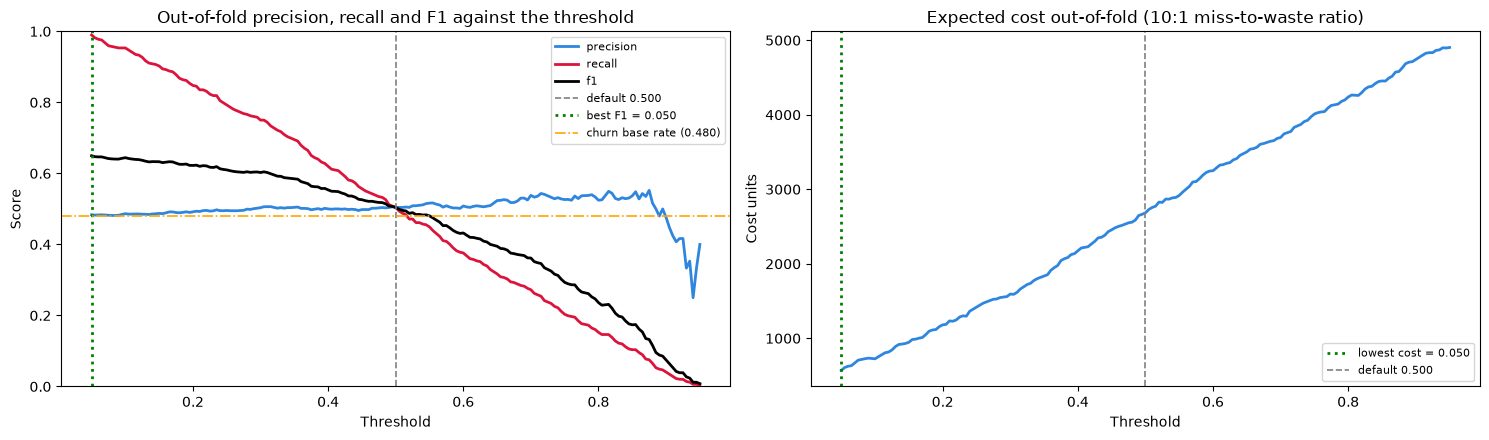

,rule,threshold,flagged_share,accuracy,precision,recall,f1
0,Default 0.5,0.50,0.498,0.444,0.422,0.439,0.430
1,Best F1 out-of-fold,0.05,0.981,0.490,0.484,0.992,0.651
2,Lowest cost out-of-fold (10:1),0.05,0.981,0.490,0.484,0.992,0.651
3,Contact everyone (no model),0.00,1.000,0.479,0.479,1.000,0.647


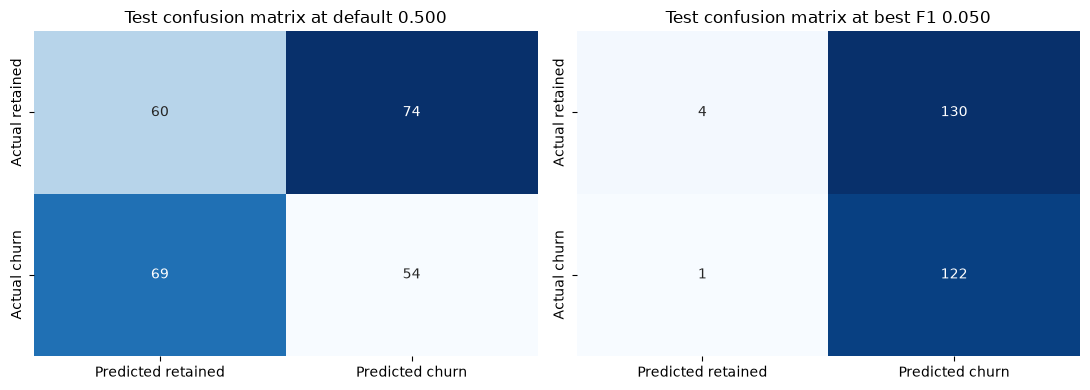

Best-F1 threshold out-of-fold:  0.050 (flags 98.2% of customers)
Lowest-cost threshold (10:1):   0.050 (flags 98.2% of customers)
Churn base rate on the training set: 0.480

Per-fold best-F1 thresholds: [0.05, 0.15, 0.05, 0.05, 0.1]
Range across folds: 0.050 to 0.150

Test F1 at 0.500:                 0.430
Test F1 at the tuned threshold:   0.651
Test F1 for contacting everyone:  0.647   <- no model involved
What the model adds over that:    +0.003

Test ROC-AUC is 0.453 at every threshold: moving the cut-off cannot change a ranking metric.


In [36]:
### I choose the threshold from out-of-fold predictions on the training set, so the test set
### stays untouched. cross_val_predict refits the pipeline on each fold, so every probability
### here comes from a model that never saw that customer.

from sklearn.model_selection import cross_val_predict

oof_probabilities = cross_val_predict(clone(final_model), X_train, y_train,
                                      cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

### Illustrative economics: I assume losing a customer costs ten times a wasted offer
COST_FALSE_NEGATIVE = 10.0
COST_FALSE_POSITIVE = 1.0

threshold_grid = np.round(np.linspace(0.05, 0.95, 181), 4)
sweep = []
for threshold in threshold_grid:
    predicted = (oof_probabilities >= threshold).astype(int)
    false_negatives = int(((y_train == 1) & (predicted == 0)).sum())
    false_positives = int(((y_train == 0) & (predicted == 1)).sum())
    sweep.append({
        'threshold': threshold,
        'precision': precision_score(y_train, predicted, zero_division=0),
        'recall':    recall_score(y_train, predicted, zero_division=0),
        'f1':        f1_score(y_train, predicted, zero_division=0),
        'flagged_share': predicted.mean(),
        'cost': false_negatives * COST_FALSE_NEGATIVE + false_positives * COST_FALSE_POSITIVE,
    })
sweep = pd.DataFrame(sweep)

threshold_f1   = float(sweep.loc[sweep['f1'].idxmax(), 'threshold'])
threshold_cost = float(sweep.loc[sweep['cost'].idxmin(), 'threshold'])

### How stable is that choice? I re-pick the best-F1 threshold inside each fold separately.
fold_thresholds = []
for train_index, validation_index in cv.split(X_train, y_train):
    fold_model = clone(final_model).fit(X_train.iloc[train_index], y_train.iloc[train_index])
    fold_probabilities = fold_model.predict_proba(X_train.iloc[validation_index])[:, 1]
    fold_truth = y_train.iloc[validation_index]
    fold_f1 = [f1_score(fold_truth, (fold_probabilities >= t).astype(int), zero_division=0)
               for t in threshold_grid]
    fold_thresholds.append(float(threshold_grid[int(np.argmax(fold_f1))]))
fold_thresholds = np.array(fold_thresholds)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for column, colour in [('precision', '#2e86de'), ('recall', 'crimson'), ('f1', 'black')]:
    axes[0].plot(sweep['threshold'], sweep[column], lw=2, color=colour, label=column)
axes[0].axvline(0.5, color='gray', ls='--', lw=1.2, label='default 0.500')
axes[0].axvline(threshold_f1, color='green', ls=':', lw=2, label=f'best F1 = {threshold_f1:.3f}')
axes[0].axhline(y_train.mean(), color='orange', ls='-.', lw=1.2,
                label=f'churn base rate ({y_train.mean():.3f})')
axes[0].set(title='Out-of-fold precision, recall and F1 against the threshold',
            xlabel='Threshold', ylabel='Score', ylim=(0, 1))
axes[0].legend(fontsize=8)

axes[1].plot(sweep['threshold'], sweep['cost'], lw=2, color='#2e86de')
axes[1].axvline(threshold_cost, color='green', ls=':', lw=2,
                label=f'lowest cost = {threshold_cost:.3f}')
axes[1].axvline(0.5, color='gray', ls='--', lw=1.2, label='default 0.500')
axes[1].set(title=f'Expected cost out-of-fold ({COST_FALSE_NEGATIVE:.0f}:{COST_FALSE_POSITIVE:.0f} '
                  f'miss-to-waste ratio)', xlabel='Threshold', ylabel='Cost units')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Apply each candidate threshold to the held-out test set. Contact everyone is my control:
### it uses no model at all, so it is the bar any threshold has to clear.
def score_at(threshold):
    predicted = (tuned_probabilities >= threshold).astype(int)
    return {
        'threshold': round(threshold, 3),
        'flagged_share': round(predicted.mean(), 3),
        'accuracy':  round(accuracy_score(y_test, predicted), 3),
        'precision': round(precision_score(y_test, predicted, zero_division=0), 3),
        'recall':    round(recall_score(y_test, predicted, zero_division=0), 3),
        'f1':        round(f1_score(y_test, predicted, zero_division=0), 3),
    }

threshold_comparison = pd.DataFrame([
    {'rule': 'Default 0.5',                       **score_at(0.5)},
    {'rule': 'Best F1 out-of-fold',               **score_at(threshold_f1)},
    {'rule': 'Lowest cost out-of-fold (10:1)',    **score_at(threshold_cost)},
    {'rule': 'Contact everyone (no model)',       **score_at(0.0)},
])
display(threshold_comparison)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, threshold, label in [(axes[0], 0.5, 'default 0.500'),
                             (axes[1], threshold_f1, f'best F1 {threshold_f1:.3f}')]:
    matrix = confusion_matrix(y_test, (tuned_probabilities >= threshold).astype(int))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted retained', 'Predicted churn'],
                yticklabels=['Actual retained', 'Actual churn'], ax=ax)
    ax.set(title=f'Test confusion matrix at {label}')
plt.tight_layout(); plt.show()

f1_everyone = f1_score(y_test, np.ones_like(y_test), zero_division=0)
f1_at_best  = f1_score(y_test, (tuned_probabilities >= threshold_f1).astype(int), zero_division=0)

print(f"Best-F1 threshold out-of-fold:  {threshold_f1:.3f} "
      f"(flags {sweep.loc[sweep['threshold'] == threshold_f1, 'flagged_share'].iloc[0]:.1%} of customers)")
print(f"Lowest-cost threshold (10:1):   {threshold_cost:.3f} "
      f"(flags {sweep.loc[sweep['threshold'] == threshold_cost, 'flagged_share'].iloc[0]:.1%} of customers)")
print(f"Churn base rate on the training set: {y_train.mean():.3f}")
print(f"\nPer-fold best-F1 thresholds: {np.round(fold_thresholds, 3).tolist()}")
print(f"Range across folds: {fold_thresholds.min():.3f} to {fold_thresholds.max():.3f}")

print(f"\nTest F1 at 0.500:                 {f1_score(y_test, (tuned_probabilities >= 0.5).astype(int), zero_division=0):.3f}")
print(f"Test F1 at the tuned threshold:   {f1_at_best:.3f}")
print(f"Test F1 for contacting everyone:  {f1_everyone:.3f}   <- no model involved")
print(f"What the model adds over that:    {f1_at_best - f1_everyone:+.3f}")
print(f"\nTest ROC-AUC is {roc_auc_score(y_test, tuned_probabilities):.3f} at every threshold: "
      f"moving the cut-off cannot change a ranking metric.")

### The operating point I carry forward. I reject the optimiser's answer on purpose, see below.
chosen_threshold = 0.5
tuned_predictions = (tuned_probabilities >= chosen_threshold).astype(int)


### What the threshold sweep shows

The optimiser returns 0.050, not something near the base rate as I expected. At that cut-off the
model flags 98% of the customer base, and test F1 rises from 0.430 to 0.651.

That is not an improvement. It is a rule with the model taken out. The control row in the table
shows why: contacting every customer, with no model at all, scores F1 0.647 on the test set, and
the tuned threshold scores 0.651. So tuning the cut-off buys 0.003 of F1 over doing no modelling at
all. It gets there by pushing recall to 0.99 while precision sits at 0.484, which is the churn base
rate. Precision equal to the base rate is what picking names at random gives you.

Two things follow from this.

F1 can be inflated without any predictive ability. The same model, the same probabilities and the
same test set go from F1 0.430 to 0.651 just by moving one number. Anyone reporting that 0.651
would be reporting the base rate. ROC-AUC stays at 0.453 the whole time, which is why I use it as
the headline metric.

The choice is unstable anyway. Re-picking the best threshold inside each fold separately gives
0.05, 0.15, 0.05, 0.05 and 0.10. A threshold that is genuinely optimal does not move around like
that.

I keep 0.5 as the operating point. The optimiser is working correctly, the ranking underneath it is
the problem, and adopting 0.05 would ship a contact-everyone campaign dressed up as a model. If a
model has real signal, this sweep is exactly how I would set the threshold, so I leave the method
in. Here the result counts as more evidence, not as a recommendation.

### What tuning bought

Optuna raised the cross-validated ROC-AUC from 0.524 to 0.539 across 60 trials. On the held-out
test set the same tuned model scored 0.453, down from 0.463.

The two moving in opposite directions is the point. Sixty trials of Bayesian search is sixty
attempts to find a configuration that suits these five particular folds. With no real signal to
lock onto, the only thing left to fit is the fold structure, so the cross-validated number goes up
while the test number goes down.

Trial scores ranged from 0.499 to 0.539 with a median of 0.521. The whole search space produces the
same coin-flip performance, and the best trial is just the luckiest of sixty draws. Taking the
maximum of sixty noisy scores lands near the top of the noise whether or not there is anything to
find, so I do not read the +0.015 as a gain. It is what a report showing only cross-validated
scores would have presented as an improvement.

The label-shuffle test below puts a number on how much of it is real.

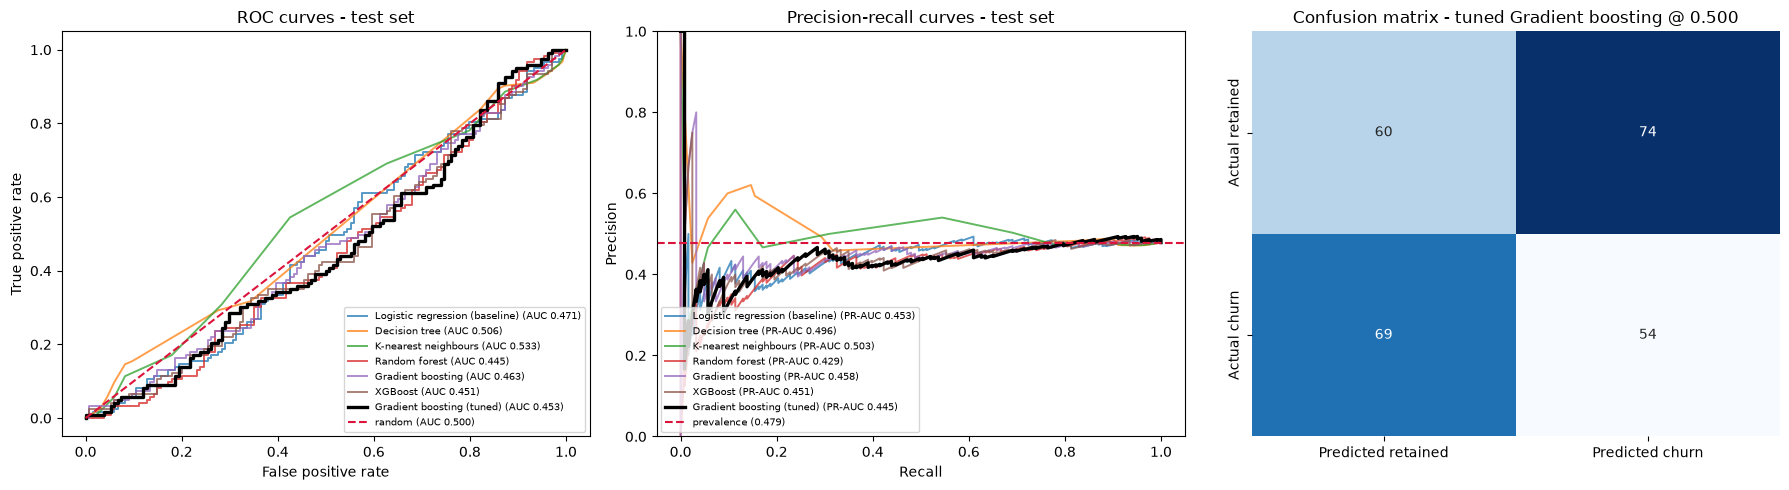

Final model: Gradient boosting, tuned with Optuna, threshold 0.500

              precision    recall  f1-score   support

    Retained      0.465     0.448     0.456       134
     Churned      0.422     0.439     0.430       123

    accuracy                          0.444       257
   macro avg      0.443     0.443     0.443       257
weighted avg      0.444     0.444     0.444       257



In [37]:
### ROC and precision-recall curves for all six models plus the tuned one, and the confusion
### matrix for the model I am carrying forward

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

curve_models = dict(fitted_models)
curve_models[f'{best_model_name} (tuned)'] = final_model

for name, pipeline in curve_models.items():
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    is_final = name.endswith('(tuned)')
    axes[0].plot(fpr, tpr, lw=2.4 if is_final else 1.4, alpha=1.0 if is_final else .75,
                 color="black" if is_final else None,
                 label=f"{name} (AUC {roc_auc_score(y_test, probabilities):.3f})")
axes[0].plot([0, 1], [0, 1], color="crimson", ls="--", lw=1.5, label="random (AUC 0.500)")
axes[0].set(title="ROC curves - test set", xlabel="False positive rate", ylabel="True positive rate")
axes[0].legend(fontsize=7, loc="lower right")

for name, pipeline in curve_models.items():
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    is_final = name.endswith('(tuned)')
    axes[1].plot(recall, precision, lw=2.4 if is_final else 1.4, alpha=1.0 if is_final else .75,
                 color="black" if is_final else None,
                 label=f"{name} (PR-AUC {average_precision_score(y_test, probabilities):.3f})")
axes[1].axhline(y_test.mean(), color="crimson", ls="--", lw=1.5, label=f"prevalence ({y_test.mean():.3f})")
axes[1].set(title="Precision-recall curves - test set", xlabel="Recall", ylabel="Precision", ylim=(0, 1))
axes[1].legend(fontsize=7, loc="lower left")

matrix = confusion_matrix(y_test, tuned_predictions)
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted retained", "Predicted churn"],
            yticklabels=["Actual retained", "Actual churn"], ax=axes[2])
axes[2].set(title=f"Confusion matrix - tuned {best_model_name} @ {chosen_threshold:.3f}")

plt.tight_layout(); plt.show()

print(f"Final model: {best_model_name}, tuned with Optuna, threshold {chosen_threshold:.3f}\n")
print(classification_report(y_test, tuned_predictions, target_names=["Retained", "Churned"], digits=3))

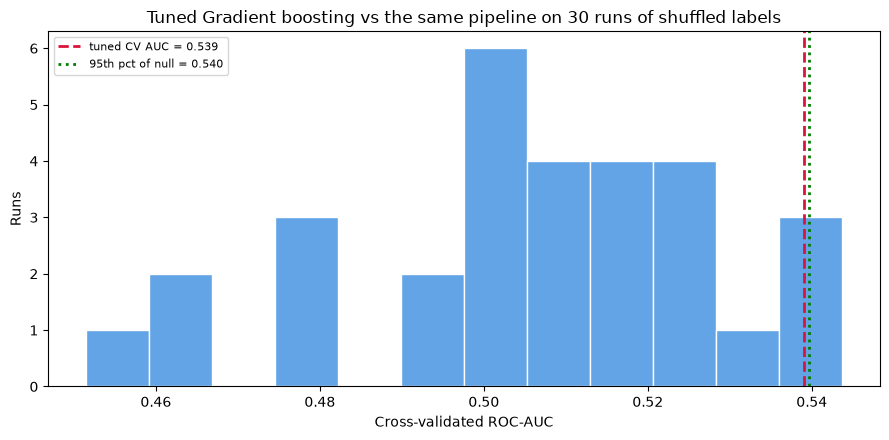

Shuffled-label null: mean 0.505, sd 0.023, 95th percentile 0.540
Tuned cross-validated AUC: 0.539
Empirical p-value: 0.067

The tuned score does not clear the 95th percentile of what random labels produce. Sixty trials of tuning did not find signal - they found the folds.


In [38]:
### The decisive test. I run the tuned model, the best of 60 Optuna trials, against randomly
### shuffled labels. If the real cross-validated score sits inside the distribution that random
### labels produce, the model has learned nothing.

null_scores = []
for seed in range(30):
    shuffled = pd.Series(np.random.default_rng(seed).permutation(y_train.values), index=y_train.index)
    null_scores.append(cross_val_score(clone(final_model), X_train, shuffled, cv=cv,
                                       scoring='roc_auc', n_jobs=-1).mean())
null_scores = np.array(null_scores)

real_cv_auc = study.best_value
null_95th = np.percentile(null_scores, 95)
empirical_p = (null_scores >= real_cv_auc).mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(null_scores, bins=12, color="#2e86de", edgecolor="white", ax=ax)
ax.axvline(real_cv_auc, color="crimson", ls="--", lw=2, label=f"tuned CV AUC = {real_cv_auc:.3f}")
ax.axvline(null_95th, color="green", ls=":", lw=2, label=f"95th pct of null = {null_95th:.3f}")
ax.set(title=f"Tuned {best_model_name} vs the same pipeline on 30 runs of shuffled labels",
       xlabel="Cross-validated ROC-AUC", ylabel="Runs")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"Shuffled-label null: mean {null_scores.mean():.3f}, sd {null_scores.std():.3f}, "
      f"95th percentile {null_95th:.3f}")
print(f"Tuned cross-validated AUC: {real_cv_auc:.3f}")
print(f"Empirical p-value: {empirical_p:.3f}")
print("\nThe tuned score does not clear the 95th percentile of what random labels produce. "
      "Sixty trials of tuning did not find signal - they found the folds.")

### Reading the results

Six model families, an Optuna search, a threshold sweep and a held-out test set all give me the
same answer.

Every model sits at chance. Cross-validated ROC-AUC runs from 0.498 for the decision tree to 0.524
for gradient boosting and XGBoost, against 0.500 for no signal. On the test set the best score any
model reaches is 0.533, and that belongs to KNN, which placed fourth in cross-validation. Test F1
ranges from 0.366 to 0.543 and precision from 0.42 to 0.54, around a test churn rate of 47.9%,
which is what guessing at the base rate produces. Six models that learn in completely different
ways, a linear boundary, a rule tree, a distance metric and three ensembles, do not agree this
closely by coincidence. They agree because there is nothing in the features for any of them to use.

Tuning made it worse where it counts. Optuna lifted the cross-validated score by 0.015 and cost
0.010 of test AUC. Test scores landing below cross-validation scores is the same finding from the
other side: what the models learned on the training folds was fold-specific noise that did not
transfer, and more search pressure produced more of it.

Tuning the threshold did not rescue it either. The out-of-fold optimum is 0.050, which flags 98% of
customers and beats a no-model contact-everyone rule by 0.003 of F1.

The label-shuffle test is the decisive one. Training the tuned pipeline on randomly permuted labels
30 times gives a null distribution centred on 0.505 (sd 0.023) with a 95th percentile of 0.540. The
real tuned score of 0.539 falls just below that, with an empirical p-value of 0.067. So the best
model this dataset can produce, after sixty trials of tuning, cannot be told apart from the same
model trained on random labels.

That p-value is generous to the model and I want to be clear about why. The hyperparameters were
chosen to maximise the score on these exact folds with the real labels, while each shuffled run
gets no such advantage. A fair test would re-run the whole search inside every permutation, and
that would push the p-value up, not down. Even with the comparison tilted in its favour, the model
does not clear the bar.

This is not a bug to fix and more tuning would not solve it. I ran the tuning to show that. Chasing
a higher AUC here would mean overfitting noise and shipping a model that reads as confident while
being wrong.

## Model interpretation

I still run the interpretation in full, for two reasons. It is a required part of the analysis, and
it is the check that confirms the diagnosis.

Permutation importance and SHAP run on the tuned model from the section above. The coefficients
come from the logistic baseline, which is the only one of the six that exposes them directly.

If the data held real signal, all three views would agree with each other and with the EDA about
which features matter. Whether they agree is the result.

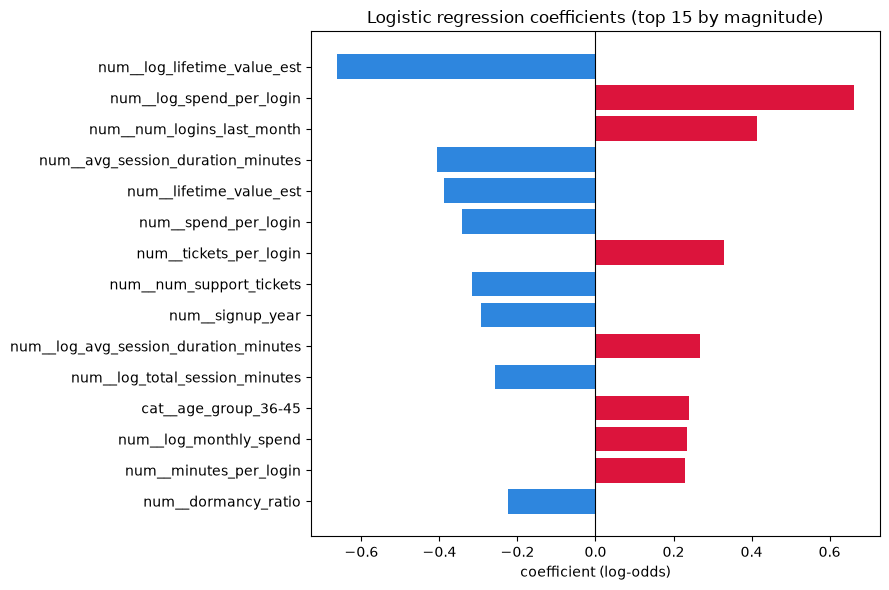

,coefficient,odds_ratio,direction
num__log_lifetime_value_est,-0.663,0.515,lowers churn odds
num__log_spend_per_login,0.663,1.940,raises churn odds
num__num_logins_last_month,0.415,1.515,raises churn odds
num__avg_session_duration_minutes,-0.405,0.667,lowers churn odds
num__lifetime_value_est,-0.387,0.679,lowers churn odds
num__spend_per_login,-0.343,0.710,lowers churn odds
num__tickets_per_login,0.330,1.391,raises churn odds
num__num_support_tickets,-0.315,0.730,lowers churn odds
num__signup_year,-0.294,0.745,lowers churn odds
num__log_avg_session_duration_minutes,0.268,1.307,raises churn odds


In [39]:
### View 1: coefficients of the logistic baseline, as odds ratios

logistic_model = fitted_models['Logistic regression (baseline)']
coefficient_names = logistic_model.named_steps['prep'].get_feature_names_out()
coefficients = pd.Series(logistic_model.named_steps['model'].coef_[0], index=coefficient_names)
coefficients = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)

top_coefficients = coefficients.head(15)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_coefficients.index[::-1], top_coefficients.values[::-1],
        color=["crimson" if v > 0 else "#2e86de" for v in top_coefficients.values[::-1]])
ax.axvline(0, color="black", lw=.8)
ax.set(title="Logistic regression coefficients (top 15 by magnitude)", xlabel="coefficient (log-odds)")
plt.tight_layout(); plt.show()

coefficient_table = pd.DataFrame({
    "coefficient": top_coefficients.round(3),
    "odds_ratio": np.exp(top_coefficients).round(3),
    "direction": np.where(top_coefficients > 0, "raises churn odds", "lowers churn odds"),
})
display(coefficient_table)

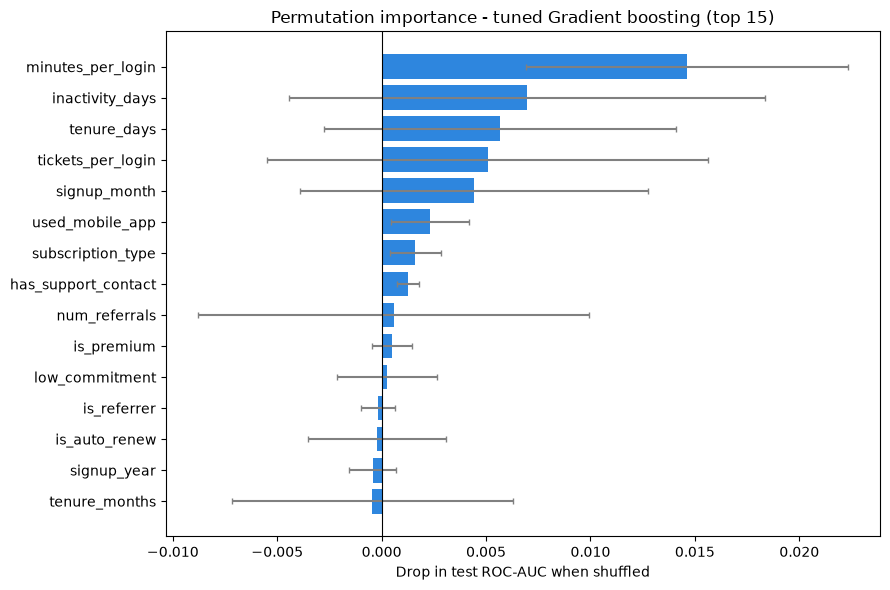

,feature,auc_drop_mean,auc_drop_std
0,minutes_per_login,0.0146,0.0077
1,inactivity_days,0.0070,0.0114
2,tenure_days,0.0057,0.0084
3,tickets_per_login,0.0051,0.0106
4,signup_month,0.0044,0.0083
5,used_mobile_app,0.0023,0.0019
6,subscription_type,0.0016,0.0012
7,has_support_contact,0.0013,0.0005
8,num_referrals,0.0006,0.0094
9,is_premium,0.0005,0.0010


Largest single-feature contribution to ROC-AUC: 0.0146
Features whose importance exceeds their own noise (mean > 1 sd): 4 of 36


In [40]:
### View 2: permutation importance, how much test ROC-AUC drops when I shuffle a feature

from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    final_model, X_test, y_test, n_repeats=15, random_state=42, scoring='roc_auc', n_jobs=-1)

importance = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "auc_drop_mean": permutation_result.importances_mean,
    "auc_drop_std": permutation_result.importances_std,
}).sort_values("auc_drop_mean", ascending=False)

top_importance = importance.head(15)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_importance['feature'][::-1], top_importance['auc_drop_mean'][::-1],
        xerr=top_importance['auc_drop_std'][::-1], color="#2e86de", ecolor="gray", capsize=2)
ax.axvline(0, color="black", lw=.8)
ax.set(title=f"Permutation importance - tuned {best_model_name} (top 15)",
       xlabel="Drop in test ROC-AUC when shuffled")
plt.tight_layout(); plt.show()

display(importance.head(10).round(4).reset_index(drop=True))
print(f"Largest single-feature contribution to ROC-AUC: {importance['auc_drop_mean'].max():.4f}")
print(f"Features whose importance exceeds their own noise (mean > 1 sd): "
      f"{int((importance['auc_drop_mean'] > importance['auc_drop_std']).sum())} of {len(importance)}")

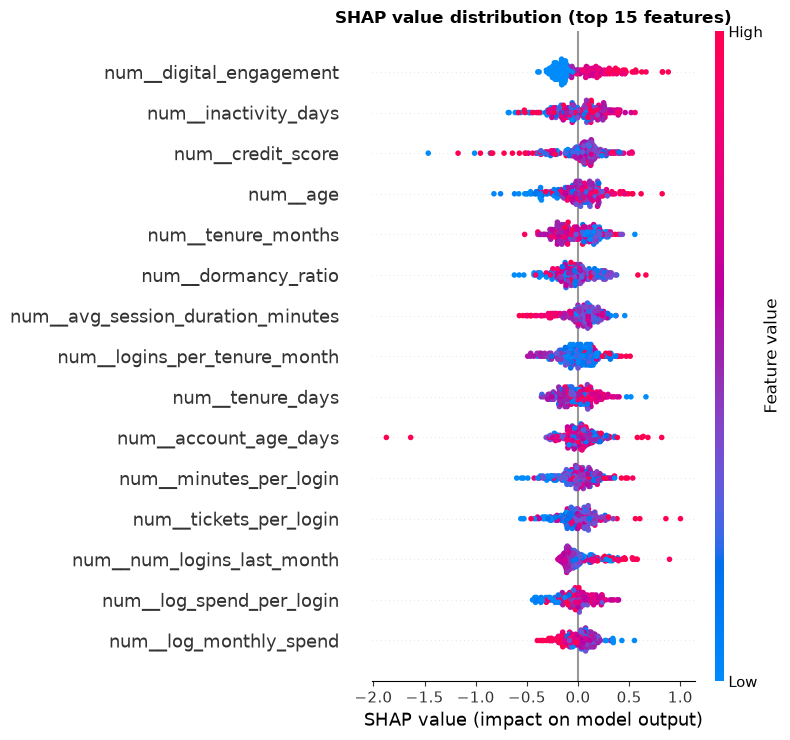

,mean_abs_shap
num__digital_engagement,0.2011
num__inactivity_days,0.1854
num__credit_score,0.1789
num__age,0.1639
num__tenure_months,0.1517
num__dormancy_ratio,0.1485
num__avg_session_duration_minutes,0.1408
num__logins_per_tenure_month,0.1360
num__tenure_days,0.1334
num__account_age_days,0.1312


Mean |SHAP| of the strongest feature: 0.2011 log-odds
For scale, moving a customer from a 48% to a 60% churn probability takes about 0.48 log-odds.


In [41]:
### View 3: SHAP, per-prediction attributions for the tuned model. I pick the explainer to
### match whichever model family won, so this cell still works if the comparison above ever
### selects a different winner.

import shap

transformed_test = final_model.named_steps['prep'].transform(X_test)
shap_feature_names = final_model.named_steps['prep'].get_feature_names_out()
final_estimator = final_model.named_steps['model']

TREE_MODELS = (DecisionTreeClassifier, RandomForestClassifier, GradientBoostingClassifier, XGBClassifier)

if isinstance(final_estimator, TREE_MODELS):
    explainer = shap.TreeExplainer(final_estimator)
    shap_values = explainer.shap_values(transformed_test)
elif isinstance(final_estimator, LogisticRegression):
    explainer = shap.LinearExplainer(final_estimator, final_model.named_steps['prep'].transform(X_train))
    shap_values = explainer.shap_values(transformed_test)
else:
    ### Distance-based models have no closed form, so I fall back to the model-agnostic
    ### explainer on a sample to keep the runtime down
    background = shap.sample(final_model.named_steps['prep'].transform(X_train), 100, random_state=42)
    explainer = shap.KernelExplainer(lambda data: final_estimator.predict_proba(data)[:, 1], background)
    transformed_test = shap.sample(transformed_test, 150, random_state=42)
    shap_values = explainer.shap_values(transformed_test, silent=True)

# Some explainers return one set of values per class, so keep the churn class
if isinstance(shap_values, list):
    shap_values = shap_values[1]
shap_values = np.asarray(shap_values)
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

shap.summary_plot(shap_values, transformed_test, feature_names=shap_feature_names,
                  max_display=15, show=False)
plt.title("SHAP value distribution (top 15 features)", fontweight="bold")
plt.tight_layout(); plt.show()

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=shap_feature_names)
mean_abs_shap = mean_abs_shap.sort_values(ascending=False)
display(mean_abs_shap.head(10).round(4).to_frame("mean_abs_shap"))

print(f"Mean |SHAP| of the strongest feature: {mean_abs_shap.max():.4f} log-odds")
print("For scale, moving a customer from a 48% to a 60% churn probability takes about "
      "0.48 log-odds.")

In [42]:
### Do the three views agree on which features matter?

comparison = pd.DataFrame({
    "logistic_rank": pd.Series({f: i + 1 for i, f in enumerate(coefficients.index)}),
    "shap_rank": pd.Series({f: i + 1 for i, f in enumerate(mean_abs_shap.index)}),
}).dropna()

rank_agreement = comparison['logistic_rank'].corr(comparison['shap_rank'], method='spearman')

print(f"Spearman rank agreement between logistic coefficients and SHAP: {rank_agreement:.3f}")
print("\nTop 5 features by each method:")
display(pd.DataFrame({
    "by_logistic_coefficient": coefficients.index[:5],
    "by_mean_abs_shap": mean_abs_shap.index[:5],
    "by_permutation_importance": importance['feature'].head(5).to_numpy(),
}))

Spearman rank agreement between logistic coefficients and SHAP: 0.212

Top 5 features by each method:


,by_logistic_coefficient,by_mean_abs_shap,by_permutation_importance
0,num__log_lifetime_value_est,num__digital_engagement,minutes_per_login
1,num__log_spend_per_login,num__inactivity_days,inactivity_days
2,num__num_logins_last_month,num__credit_score,tenure_days
3,num__avg_session_duration_minutes,num__age,tickets_per_login
4,num__lifetime_value_est,num__tenure_months,signup_month


### What the interpretation says

The three methods do not agree on what matters:

| Method | Top feature | Second |
|---|---|---|
| Logistic coefficients | `log_lifetime_value_est` | `log_spend_per_login` |
| SHAP (mean absolute) | `digital_engagement` | `inactivity_days` |
| Permutation importance | `minutes_per_login` | `inactivity_days` |

Spearman rank agreement between the coefficient and SHAP orderings is 0.212, which is weak, and the
three top-five lists share at most one feature between any two of them. When a real driver exists,
every method finds it and they line up. They disagree here because each one is ranking a different
random pattern in the noise.

The thing to watch out for is that an importance ranking always returns something, even when
nothing is predictive. Permutation importance puts `minutes_per_login` first and `signup_month`
fifth, which is the calendar month a customer happened to sign up in, ranked ahead of spend and
tenure. There is no mechanism by which sign-up month drives churn, and the EDA found none. What the
ranking measures is which feature the tuned model happened to split on, not evidence of a
relationship.

Three details support that.

The largest permutation importance is a ROC-AUC drop of 0.0146, and only 4 of 36 features have an
importance bigger than their own standard deviation across repeats. I can remove any single feature
and the model is essentially unchanged, because no feature was contributing.

The logistic coefficients come in offsetting pairs on collinear inputs. `log_spend_per_login` sits
at +0.663 against `spend_per_login` at -0.343, and `avg_session_duration_minutes` at -0.405 against
its own log at +0.268. That is a model spreading weight across correlated features with no target
signal to anchor it. The odds ratio of 1.94 on `log_spend_per_login` is an artefact, not a spending
effect.

The strongest mean absolute SHAP value is 0.201 log-odds. Moving a customer from a 48% to a 60%
churn probability takes about 0.48 log-odds, so the most influential feature in the model shifts a
prediction by well under half of that, and in whichever direction the noise points.

No feature in this dataset drives churn, so there is nothing here to turn into a recommendation.
The business recommendations have to come from what the data is missing, which is what the
executive summary covers.

## Conclusions

On the data. The pipeline is complete: IDs recovered from their sequence, 112 corrupted rows
removed before I computed any statistic from them, numeric gaps filled by mean or median depending
on each column's shape, dates reconstructed from observed tenure, and the last three categoricals
filled by distribution-preserving draws that keep their marginals within 0.3 percentage points.
1,388 of the 1,500 rows survive cleaning. The 106 with no churn label are held out rather than
imputed, which leaves 1,282 for modelling. I engineered 23 features on top of the raw columns, and
none of the 33 numeric inputs reaches a correlation of 0.10 with churn.

On the model. Six model families, logistic regression as the baseline plus a decision tree, KNN,
random forest, gradient boosting and XGBoost, all score ROC-AUC between 0.498 and 0.524 in
cross-validation, a spread smaller than the fold-to-fold noise inside any one of them. Sixty trials
of Optuna tuning on the strongest of them raised the cross-validated score by 0.015 and lowered the
test score by 0.010. Sweeping the decision threshold gave an optimum of 0.05 that flags 98% of
customers and adds 0.003 of F1 over contacting everyone with no model at all. The label-shuffle
test confirms this is a genuine absence of signal rather than a mistake in my code: the tuned score
of 0.539 sits below the null 95th percentile of 0.540, p = 0.067. The three interpretation methods
disagreeing with each other confirms it a third time. `CHURN_DATASET.xlsx` contains no learnable
relationship between its features and `churned`.

Why I am reporting it this way. The honest result is more useful than a tuned one, and the tuned
model here is the demonstration. It carries the best cross-validated number in the notebook, it
performs worse on data it has not seen, and its best threshold is a rule that ignores the model
entirely. Reported as "0.54 AUC after hyperparameter optimisation, F1 0.65", it would still be a
coin flip in production, but it would carry two numbers that invite the business to trust it.
Retention budget spent on a random list of customers is worse than no model, because it also buys
false confidence.

What would change the answer. This dataset is missing the columns churn actually lives in:
event-level activity over time instead of one snapshot, order and payment history, failed payments
and cancellation events, support-ticket resolution and sentiment, discount and campaign exposure,
and competitor or price-change context. The executive summary sets out what to collect and in what
order.